#  V2V-LSTM Model Using the inD Dataset

This notebook is designed to avoid the main reason my previous model achieved suspiciously high accuracy: **the model was learning labels created from deterministic V2V rules using the same rule variables as input features**.

In this version, the model predicts an **observed future behaviour label** from trajectory data. The target is derived from the vehicle's future movement over a short horizon, while the input features use only current and past information.

Main improvements:

- Understand the dataset before training.
- Use all recordings 07–17.
- Remove parked/stationary/short tracks.
- Estimate intersection center after filtering moving vehicles.
- Infer approach and maneuver using trajectory segments.
- Create labels from **future observed behaviour**, not from current rule decisions.
- Avoid target leakage features such as previous GO/YIELD message counts.
- Split train/validation/test by recording, not random frames.
- Evaluate using accuracy, balanced accuracy, macro F1, classification report, and confusion matrix.



## Cell 1: Import Libraries

This cell imports all required libraries. It also sets random seeds so model results are more reproducible.

In [1]:
# ================================
# Cell 1: Import libraries
# ================================

import os
import glob
import math
import random
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils import class_weight
import joblib

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print("TensorFlow loaded successfully:", tf.__version__)
except Exception as e:
    tf = None
    print("TensorFlow is not available. Install TensorFlow before training the LSTM model.")
    print("Error:", e)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if tf is not None:
    tf.random.set_seed(RANDOM_SEED)

print("Libraries imported successfully.")

TensorFlow loaded successfully: 2.20.0
Libraries imported successfully.


# Cell 2: User Configuration

This cell contains the main settings used by the notebook.

Here we define:

1. **Dataset location**
   - The notebook tries several possible folder paths to find the inD dataset.
   - This is useful because the dataset path can be different in Google Colab, local computer, or sandbox environment.

2. **Selected recordings**
   - We choose which inD dataset recordings will be used for training/testing.
   - Here recordings from 7 to 17 are selected.

3. **Distance thresholds**
   - These values help identify when vehicles are close enough to be considered important for V2V interaction.
   - `THRESHOLD_DISTANCE` is a wider warning zone.
   - `DECISION_DISTANCE` is a closer decision-making zone.

4. **Moving vehicle filtering**
   - Some vehicles may be parked or almost not moving.
   - These filtering rules remove such vehicles, because we only want useful moving-vehicle behaviour.

5. **V2V interaction context**
   - These settings describe how far vehicles can communicate/interact and how close their arrival times are.

6. **Future behaviour label creation**
   - The model does not use manually given labels.
   - Instead, it looks at what the vehicle actually does in the next 1 second.
   - Based on future movement, the notebook creates labels like GO, YIELD, or WAIT.

7. **LSTM settings**
   - `SEQUENCE_LENGTH = 10` means the LSTM sees 10 time steps before predicting behaviour.
   - This helps the model learn movement patterns over time.

8. **Output folder**
   - The notebook creates a folder to save generated files such as processed data, scaler, label encoder, model, and results.

In simple words, this cell is the control panel of the notebook.  
We define all important values here so that we can easily change the experiment without editing the full code.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ================================
# Cell 2: User configuration
# ================================

# The notebook will try these dataset paths in order.
# In Google Colab, update DATA_ROOT manually if your dataset is stored elsewhere.
DATA_ROOT_CANDIDATES = [
    "/content/drive/MyDrive/inD-dataset-v1.1/data",
    "/content/Data",
    "/content/data",
    "/mnt/data/Data_extracted/Data",   # useful only when running in this sandbox
]

# If you upload Data.zip to Colab, this notebook can extract it.


# Selected inD recordings.
RECORDING_IDS = list(range(7, 18))

# Distance zones in meters.
THRESHOLD_DISTANCE = 35.0
DECISION_DISTANCE = 20.0

# Moving-track filtering rules.
MIN_TRACK_FRAMES = 25              # at least 1 second at 25 fps
MIN_DISPLACEMENT_M = 10.0          # remove parked/static vehicles
MIN_MEAN_SPEED_MPS = 1.0           # remove almost-stationary vehicles

# V2V interaction context.
INTERACTION_RADIUS_M = 50.0
SAFE_ETA_GAP = 1.0
ETA_CLOSE_THRESHOLD = 1.0

# Future-behaviour label creation.
# Label is derived from observed motion over the next horizon, not from a V2V rule.
FUTURE_HORIZON_SECONDS = 1.0
ROW_STRIDE_FRAMES = 5              # sample every 5 frames to reduce near-duplicate rows
YIELD_SPEED_DROP_MPS = 1.5
YIELD_DECELERATION_MPS2 = -1.0
GO_PROGRESS_M = 2.0
GO_MIN_FUTURE_SPEED_MPS = 1.0

# LSTM settings.
SEQUENCE_LENGTH = 10
MIN_SAMPLES_FOR_TRAINING = 200

# Output folder.
OUTPUT_DIR = "/content/v2v_lstm_observed_behavior_outputs"
if os.path.exists("/mnt/data"):
    OUTPUT_DIR = "/mnt/data/v2v_lstm_observed_behavior_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print("RECORDING_IDS:", RECORDING_IDS)
print("THRESHOLD_DISTANCE:", THRESHOLD_DISTANCE)
print("DECISION_DISTANCE:", DECISION_DISTANCE)
print("FUTURE_HORIZON_SECONDS:", FUTURE_HORIZON_SECONDS)
print("ROW_STRIDE_FRAMES:", ROW_STRIDE_FRAMES)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("OUTPUT_DIR:", OUTPUT_DIR)

Configuration loaded.
RECORDING_IDS: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
THRESHOLD_DISTANCE: 35.0
DECISION_DISTANCE: 20.0
FUTURE_HORIZON_SECONDS: 1.0
ROW_STRIDE_FRAMES: 5
SEQUENCE_LENGTH: 10
OUTPUT_DIR: /content/v2v_lstm_observed_behavior_outputs


# Cell 3: Locate Dataset Files

This cell finds the inD dataset folder.

The notebook first checks whether the dataset already exists in one of the paths defined in Cell 2.

If the dataset folder is not found, the notebook tries to find and extract `Data.zip`.

Main idea:

1. Check existing dataset paths.
2. If dataset is found, use that folder.
3. If dataset is not found, check whether `Data.zip` exists.
4. If `Data.zip` exists, extract it.
5. After extraction, again check possible dataset folders.
6. If still not found, stop the notebook and show an error.
7. If found, print the dataset path and show a few files inside it.

This cell is important because the next cells need CSV files from the dataset.  
Without correctly finding the dataset folder, the notebook cannot load vehicle tracks.

In [4]:
# ================================
# Cell 3: Locate dataset files
# ================================

def maybe_extract_zip():
    for zip_path in DATA_ZIP_CANDIDATES:
        if os.path.exists(zip_path):
            extract_root = "/content" if zip_path.startswith("/content") else "/mnt/data/Data_extracted_auto"
            os.makedirs(extract_root, exist_ok=True)
            print("Found zip file:", zip_path)
            print("Extracting to:", extract_root)
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(extract_root)
            return extract_root
    return None

# Try existing paths first.
DATA_ROOT = None
for candidate in DATA_ROOT_CANDIDATES:
    if os.path.exists(candidate):
        DATA_ROOT = candidate
        break

# If not found, try extracting Data.zip.
if DATA_ROOT is None:
    extracted_root = maybe_extract_zip()
    if extracted_root is not None:
        possible = [
            os.path.join(extracted_root, "Data"),
            extracted_root,
        ]
        for candidate in possible:
            if os.path.exists(candidate):
                DATA_ROOT = candidate
                break

if DATA_ROOT is None:
    raise FileNotFoundError("Dataset folder not found. Please set DATA_ROOT manually or upload Data.zip.")

print("Using DATA_ROOT:", DATA_ROOT)
print("Files in DATA_ROOT sample:")
print(os.listdir(DATA_ROOT)[:10])

Using DATA_ROOT: /content/drive/MyDrive/inD-dataset-v1.1/data
Files in DATA_ROOT sample:
['03_recordingMeta.csv', '03_tracksMeta.csv', '02_background.png', '04_background.png', '05_recordingMeta.csv', '01_tracksMeta.csv', '03_background.png', '02_tracks.csv', '05_tracksMeta.csv', '01_recordingMeta.csv']


# Cell 4: Find Recording Files

This cell checks whether the selected inD recording files are available.

In Cell 2, we selected recording IDs from 7 to 17.

For each recording, the inD dataset usually has 3 important CSV files:

1. `tracks.csv`
   - Contains frame-by-frame vehicle movement data.
   - Example: vehicle position, speed, acceleration, heading, frame number.

2. `tracksMeta.csv`
   - Contains information about each vehicle track.
   - Example: vehicle class, track length, initial frame, final frame.

3. `recordingMeta.csv`
   - Contains information about the whole recording.
   - Example: recording location, frame rate, dataset information.

This cell checks whether all 3 files exist for each selected recording.

If all 3 files are found, that recording is marked as available.

If at least one required file is missing, that recording is not used.

At the end, the cell prints:

- How many recordings are available
- Which recording IDs are available
- A table showing found/missing file paths

If no complete recordings are found, the notebook stops with an error.



In [5]:
# ================================
# Cell 4: Find recording files
# ================================

# This cell checks whether the required CSV files exist for each selected recording.
# For each recording, we need:
# 1. tracks.csv
# 2. tracksMeta.csv
# 3. recordingMeta.csv


# This function finds the 3 required CSV files for one recording ID.
# data_root = dataset folder path
# recording_id = selected recording number, example: 7, 8, 9, ...
def find_recording_files(data_root, recording_id):

    # Convert recording ID to normal string.
    # Example:
    # recording_id = 7
    # rid_plain = "7"
    rid_plain = str(recording_id)

    # Convert recording ID to 2-digit format.
    # Example:
    # recording_id = 7
    # rid_padded = "07"
    #
    # This is important because dataset files named as:
    # 07_tracks.csv instead of 7_tracks.csv
    rid_padded = f"{recording_id:02d}"


    # Create possible filename patterns for each required file type.
    # Different dataset copies may use slightly different naming styles.
    #
    # Example possible names:
    # 07_tracks.csv
    # 7_tracks.csv
    # recording07_tracks.csv
    # recording7_tracks.csv
    patterns = {

        # Possible paths for the tracks file.
        # tracks file contains actual vehicle movement data.
        "tracks": [
            os.path.join(data_root, f"{rid_padded}_tracks.csv"),
            os.path.join(data_root, f"{rid_plain}_tracks.csv"),
            os.path.join(data_root, f"recording{rid_padded}_tracks.csv"),
            os.path.join(data_root, f"recording{rid_plain}_tracks.csv"),
        ],

        # Possible paths for the tracksMeta file.
        # tracksMeta contains information about each vehicle track.
        "tracksMeta": [
            os.path.join(data_root, f"{rid_padded}_tracksMeta.csv"),
            os.path.join(data_root, f"{rid_plain}_tracksMeta.csv"),
            os.path.join(data_root, f"recording{rid_padded}_tracksMeta.csv"),
            os.path.join(data_root, f"recording{rid_plain}_tracksMeta.csv"),
        ],

        # Possible paths for the recordingMeta file.
        # recordingMeta contains information about the whole recording.
        "recordingMeta": [
            os.path.join(data_root, f"{rid_padded}_recordingMeta.csv"),
            os.path.join(data_root, f"{rid_plain}_recordingMeta.csv"),
            os.path.join(data_root, f"recording{rid_padded}_recordingMeta.csv"),
            os.path.join(data_root, f"recording{rid_plain}_recordingMeta.csv"),
        ],
    }


    # Create an output dictionary.
    # This dictionary will store recording ID and found file paths.
    out = {"recording_id": recording_id}


    # Loop through each file type in patterns.
    # key can be:
    # "tracks"
    # "tracksMeta"
    # "recordingMeta"
    #
    # paths is the list of possible paths for that file type.
    for key, paths in patterns.items():

        # Find the first path that actually exists.
        #
        # next(...) returns the first matching file path.
        # If no file path exists, it returns None.
        #
        # Example:
        # If 07_tracks.csv exists, out["tracks"] becomes that path.
        # If no tracks file exists, out["tracks"] becomes None.
        out[key] = next((p for p in paths if os.path.exists(p)), None)


    # Return the dictionary with recording ID and file paths.
    return out


# This list will store only recordings that have all 3 required files.
available_recordings = []


# This list will store information for all checked recordings.
# It includes both available and unavailable recordings.
# Later we convert this into a pandas DataFrame for easy viewing.
recording_file_rows = []


# Loop through each selected recording ID.
# RECORDING_IDS was defined in Cell 2.
# Example: 7, 8, 9, ..., 17
for rid in RECORDING_IDS:

    # Find the required files for this recording ID.
    files = find_recording_files(DATA_ROOT, rid)


    # Check whether all 3 required files are found.
    #
    # A recording is complete only if:
    # tracks file exists
    # tracksMeta file exists
    # recordingMeta file exists
    has_all = (
        files["tracks"] is not None
        and files["tracksMeta"] is not None
        and files["recordingMeta"] is not None
    )


    # Add availability result into the files dictionary.
    # True means all 3 files were found.
    # False means one or more files are missing.
    files["available"] = has_all


    # Save a copy of this recording's file information.
    # This is used later to create a table.
    recording_file_rows.append(files.copy())


    # If all required files exist, add this recording to available_recordings.
    if has_all:
        available_recordings.append(files)


# Convert the list of file information into a pandas DataFrame.
# This makes it easier to print and inspect the result as a table.
recording_files_df = pd.DataFrame(recording_file_rows)


# Print how many complete recordings were found.
print("Total available recordings:", len(available_recordings))


# Print the IDs of recordings that have all required files.
print("Available recording IDs:", [f["recording_id"] for f in available_recordings])


# Print a title before showing the table.
print("Recording file table head:")


# Print the first 20 rows of the recording file table.
# This lets us check which files were found and which are missing.
print(recording_files_df.head(20))


# If no complete recordings are found, stop the notebook.
# The next cells cannot work without complete recording files.
if len(available_recordings) == 0:
    raise FileNotFoundError("No complete recording files found.")

Total available recordings: 11
Available recording IDs: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Recording file table head:
    recording_id                                             tracks  \
0              7  /content/drive/MyDrive/inD-dataset-v1.1/data/0...   
1              8  /content/drive/MyDrive/inD-dataset-v1.1/data/0...   
2              9  /content/drive/MyDrive/inD-dataset-v1.1/data/0...   
3             10  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
4             11  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
5             12  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
6             13  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
7             14  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
8             15  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
9             16  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   
10            17  /content/drive/MyDrive/inD-dataset-v1.1/data/1...   

                      

# Cell 5: Dataset Understanding

This cell gives us a basic understanding of the selected inD dataset recordings.

In the previous cells, we found the available recording files.  
Now this cell reads the metadata files from those recordings.

For each available recording, this cell reads:

1. `tracksMeta.csv`
   - Contains information about each road user/track.
   - Example: object class, track ID, number of frames, distance travelled.

2. `recordingMeta.csv`
   - Contains information about the whole recording.
   - Example: recording ID, location, frame rate, recording details.

After reading all selected recordings, the cell combines them into two big tables:

1. `combined_tracks_meta`
   - All `tracksMeta` files combined together.

2. `combined_recording_meta`
   - All `recordingMeta` files combined together.

Then the cell prints:

- Shape of the combined metadata tables
- Object class counts
- Object class percentages
- First few rows of recording metadata
- First few rows of tracks metadata

This cell is important because before training a model, we need to understand what kind of objects exist in the dataset.

For example, the dataset may contain:

- cars
- vans
- trucks/buses
- pedestrians
- bicycles

For our vehicle behaviour research, we mostly care about vehicle-like classes such as cars, vans, and trucks/buses.

In [6]:
# ================================
# Cell 5: Dataset understanding
# ================================

def understand_dataset(available_recordings):
    meta_rows = []
    recording_rows = []

    for files in available_recordings:
        rid = files["recording_id"]
        tracks_meta = pd.read_csv(files["tracksMeta"])
        recording_meta = pd.read_csv(files["recordingMeta"])

        if "recordingId" not in tracks_meta.columns:
            tracks_meta["recordingId"] = rid
        if "recordingId" not in recording_meta.columns:
            recording_meta["recordingId"] = rid

        meta_rows.append(tracks_meta)
        recording_rows.append(recording_meta)

    combined_meta = pd.concat(meta_rows, ignore_index=True)
    combined_recording_meta = pd.concat(recording_rows, ignore_index=True)
    return combined_meta, combined_recording_meta

combined_tracks_meta, combined_recording_meta = understand_dataset(available_recordings)

print("Combined tracksMeta shape:", combined_tracks_meta.shape)
print("Combined recordingMeta shape:", combined_recording_meta.shape)
print("Object class counts:")
print(combined_tracks_meta["class"].value_counts(dropna=False))
print("Object class percentages:")
print((combined_tracks_meta["class"].value_counts(normalize=True) * 100).round(2))
print("Recording metadata head:")
print(combined_recording_meta.head())
print("TracksMeta head:")
print(combined_tracks_meta.head())

Combined tracksMeta shape: (3738, 8)
Combined recordingMeta shape: (11, 15)
Object class counts:
class
car           2444
pedestrian     801
bicycle        434
truck_bus       59
Name: count, dtype: int64
Object class percentages:
class
car           65.38
pedestrian    21.43
bicycle       11.61
truck_bus      1.58
Name: proportion, dtype: float64
Recording metadata head:
   recordingId  locationId  frameRate  speedLimit  weekday  startTime  \
0            7           1       25.0    13.88889  tuesday        NaN   
1            8           1       25.0    13.88889  tuesday        NaN   
2            9           1       25.0    13.88889  tuesday        NaN   
3           10           1       25.0    13.88889  tuesday        NaN   
4           11           1       25.0    13.88889   monday       16.0   

   duration  numTracks  numVehicles  numVRUs  latLocation  lonLocation  \
0   1055.28        212          150       62     50.78207      6.07116   
1   1065.60        415          284   

# Cell 6: Load One Recording

This cell loads the actual data from one selected inD recording.

In previous cells, we only checked whether files exist and understood the metadata.  
Now we start loading the real recording data.

For each recording, this cell reads:

1. `tracks.csv`
   - This is the main movement data.
   - It contains frame-by-frame vehicle positions, speeds, and movement values.

2. `tracksMeta.csv`
   - This contains information about each track/object.
   - It includes the object class, such as car, van, pedestrian, bicycle, etc.

3. `recordingMeta.csv`
   - This contains recording-level information.
   - Example: recording ID, frame rate, location information.

This cell also filters the dataset to keep only vehicle-like objects.

Vehicle classes used here:

- car
- truck_bus
- van
- truck
- bus

Pedestrians and bicycles are removed because this research focuses on vehicle-to-vehicle behaviour.

After filtering, the code adds the vehicle class information into the `tracks` table.  
This is useful because later we can know each row belongs to a car, van, truck, or bus.

At the end, this cell loads only the first available recording as a test.  
This is done to verify that the loading function works correctly before processing all recordings.

In simple words, this cell starts using the real vehicle movement data.

In [7]:
# ================================
# Cell 6: Load one recording
# ================================

# This cell loads one recording's actual data.
# Unlike Cell 5, this cell reads tracks.csv also.
# tracks.csv contains real frame-by-frame movement data.


# Define which object classes we want to keep.
# Since this research is about vehicle behaviour / V2V,
# we keep only vehicle-like classes.
#
# We remove classes such as pedestrian and bicycle.
VEHICLE_CLASSES = {"car", "truck_bus"}


# This function loads one complete recording.
#
# files is one item from available_recordings.
# It contains:
# - recording_id
# - tracks file path
# - tracksMeta file path
# - recordingMeta file path
def load_recording(files):

    # Get recording ID.
    # Example: 7, 8, 9, ...
    rid = files["recording_id"]


    # Read tracks.csv.
    # This is the main movement file.
    # It contains vehicle/object data for every frame.
    tracks = pd.read_csv(files["tracks"])


    # Read tracksMeta.csv.
    # This contains information about each track/object.
    # Example: trackId, class, initialFrame, finalFrame, numFrames.
    tracks_meta = pd.read_csv(files["tracksMeta"])


    # Read recordingMeta.csv.
    # This contains information about the whole recording.
    # Example: recordingId, frameRate, locationId.
    recording_meta = pd.read_csv(files["recordingMeta"])


    # Some dataset versions may not have recordingId inside tracks.csv.
    # If missing, we manually add recordingId using rid.
    #
    # This helps later when we combine many recordings together.
    if "recordingId" not in tracks.columns:
        tracks["recordingId"] = rid


    # Some dataset versions may not have recordingId inside tracksMeta.csv.
    # If missing, add it manually.
    if "recordingId" not in tracks_meta.columns:
        tracks_meta["recordingId"] = rid


    # Some dataset versions may not have recordingId inside recordingMeta.csv.
    # If missing, add it manually.
    if "recordingId" not in recording_meta.columns:
        recording_meta["recordingId"] = rid


    # Check whether tracksMeta has a class column.
    # The class column tells whether an object is car, pedestrian, bicycle, etc.
    if "class" in tracks_meta.columns:

        # Keep only rows where object class is inside VEHICLE_CLASSES.
        #
        # Example:
        # Keep: car, van, truck_bus, truck, bus
        # Remove: pedestrian, bicycle, other non-vehicle objects
        vehicle_meta = tracks_meta[tracks_meta["class"].isin(VEHICLE_CLASSES)].copy()


        # Get the track IDs of vehicle-like objects only.
        #
        # astype(int) converts trackId into integer.
        # tolist() converts it into a Python list.
        vehicle_ids = vehicle_meta["trackId"].astype(int).tolist()


        # Filter tracks.csv to keep only vehicle rows.
        #
        # tracks["trackId"].isin(vehicle_ids) checks whether each row's trackId
        # belongs to a vehicle.
        tracks = tracks[tracks["trackId"].isin(vehicle_ids)].copy()


        # Replace tracks_meta with only vehicle metadata.
        # After this, tracks_meta contains only vehicle-like objects.
        tracks_meta = vehicle_meta.copy()


        # Create a small mapping table with recordingId, trackId, and class.
        #
        # This is used to add object class into the main tracks table.
        # Example:
        # recordingId | trackId | class
        # 7           | 1       | car
        # 7           | 2       | van
        class_map = tracks_meta[["recordingId", "trackId", "class"]].drop_duplicates()


        # Merge class information into tracks table.
        #
        # Before merge:
        # tracks table has frame-by-frame movement data.
        #
        # After merge:
        # tracks table also has the class column.
        #
        # on=["recordingId", "trackId"] means we match using recordingId and trackId.
        # how="left" means keep all tracks rows and add class if available.
        tracks = tracks.merge(class_map, on=["recordingId", "trackId"], how="left")


    # Print loading summary for this recording.
    #
    # len(tracks) = number of frame rows after vehicle filtering.
    # tracks_meta["trackId"].nunique() = number of unique vehicle tracks.
    print(
        f"Recording {rid}: loaded vehicle frame rows = {len(tracks)}, "
        f"vehicle tracks = {tracks_meta['trackId'].nunique()}"
    )


    # Return the loaded data.
    #
    # tracks = vehicle movement rows
    # tracks_meta = vehicle metadata
    # recording_meta = recording information
    return tracks, tracks_meta, recording_meta


# Test load first recording only for verification.
#
# available_recordings[0] means the first available recording found in Cell 4.
# We load only one recording here to check whether the function works correctly.
test_tracks, test_tracks_meta, test_recording_meta = load_recording(available_recordings[0])


# Print first few rows of the loaded tracks data.
# This lets us check actual vehicle movement rows.
print("Test tracks head:")
print(test_tracks.head())


# Print first few rows of vehicle metadata.
# This lets us check selected vehicle tracks.
print("Test tracksMeta head:")
print(test_tracks_meta.head())


# Print first few rows of recording metadata.
# This lets us check recording-level information.
print("Test recordingMeta head:")
print(test_recording_meta.head())

Recording 7: loaded vehicle frame rows = 159929, vehicle tracks = 150
Test tracks head:
   recordingId  trackId  frame  trackLifetime   xCenter   yCenter    heading  \
0            7        0      0              0  49.08017 -24.74120  130.43668   
1            7        0      1              1  48.83219 -24.44429  130.45173   
2            7        0      2              2  48.57888 -24.14266  130.46495   
3            7        0      3              3  48.32055 -23.83694  130.48212   
4            7        0      4              4  48.05787 -23.52818  130.50529   

     width   length  xVelocity  yVelocity  xAcceleration  yAcceleration  \
0  1.93507  4.94025   -6.17783    7.41719       -1.50784        1.31554   
1  1.93507  4.94025   -6.25506    7.48254       -1.51208        1.32382   
2  1.93507  4.94025   -6.33170    7.54772       -1.49979        1.31961   
3  1.93507  4.94025   -6.40631    7.61163       -1.47211        1.30373   
4  1.93507  4.94025   -6.47771    7.67361       -1.43086

# Cell 7: Basic Kinematic Features

This cell creates basic movement-related features from the vehicle tracks.

In Cell 6, we loaded the real vehicle movement data from `tracks.csv`.  
Now Cell 7 converts that raw movement data into useful features for behaviour learning.

Kinematic features mean movement features.

This cell creates:

1. `time_s`
   - Converts frame number into time in seconds.
   - Example: if frame rate is 25 fps, frame 50 means 2 seconds.

2. `speed_mps`
   - Vehicle speed in meters per second.
   - If velocity columns exist, speed is calculated from x and y velocity.
   - If not, speed is estimated using position difference between frames.

3. `acc_mps2`
   - Acceleration magnitude in meters per second squared.
   - This tells how strongly the vehicle is accelerating or decelerating.

4. `signed_acc_mps2`
   - Signed acceleration.
   - Negative value means vehicle is slowing down / braking.
   - Positive value means vehicle is speeding up.

5. `heading_sin` and `heading_cos`
   - These encode vehicle direction using heading angle.
   - They are useful for machine learning because direction is circular.
   - Example: 359 degrees and 1 degree are almost the same direction, but numerically they look far apart.
   - Using sine and cosine helps solve that problem.

This cell also removes invalid values such as infinity and fills missing feature values with 0.

In simple words, this cell converts raw vehicle movement rows into useful speed, acceleration, time, and direction features.

In [8]:
# ================================
# Cell 7: Basic kinematic features
# ================================

# This cell creates basic movement features from tracks data.
# These features are useful for behaviour prediction and LSTM training.
#
# Kinematic features means movement-related features:
# - time
# - speed
# - acceleration
# - direction


# This function adds basic kinematic features to one recording's tracks data.
#
# tracks = frame-by-frame vehicle movement data
# recording_meta = metadata for that recording, including frame rate
def add_basic_kinematic_features(tracks, recording_meta):

    # Make a copy of tracks.
    # This protects the original tracks DataFrame from being changed directly.
    df = tracks.copy()


    # Get frame rate from recording_meta if the column exists.
    #
    # frameRate means how many frames are recorded per second.
    # inD dataset usually uses 25 frames per second.
    #
    # Example:
    # frame_rate = 25.0 means 25 frames = 1 second.
    if "frameRate" in recording_meta.columns:
        frame_rate = float(recording_meta["frameRate"].iloc[0])
    else:
        frame_rate = 25.0


    # Sort data by recordingId, trackId, and frame.
    #
    # This is very important because later we calculate differences
    # between consecutive frames.
    #
    # Correct order:
    # same recording -> same vehicle -> frame 1, frame 2, frame 3, ...
    df = df.sort_values(["recordingId", "trackId", "frame"]).copy()


    # Convert frame number into time in seconds.
    #
    # Formula:
    # time = frame / frame_rate
    #
    # Example:
    # frame = 50
    # frame_rate = 25
    # time_s = 50 / 25 = 2 seconds
    df["time_s"] = df["frame"] / frame_rate


    # ================================
    # Calculate speed
    # ================================

    # Case 1:
    # If xVelocity and yVelocity columns exist,
    # calculate speed using both velocity components.
    #
    # Formula:
    # speed = sqrt(xVelocity^2 + yVelocity^2)
    #
    # This gives total movement speed in meters per second.
    if "xVelocity" in df.columns and "yVelocity" in df.columns:
        df["speed_mps"] = np.sqrt(df["xVelocity"]**2 + df["yVelocity"]**2)


    # Case 2:
    # If xVelocity and yVelocity are not available,
    # but lonVelocity is available, use absolute longitudinal velocity.
    #
    # abs() is used because speed should be positive.
    elif "lonVelocity" in df.columns:
        df["speed_mps"] = df["lonVelocity"].abs()


    # Case 3:
    # If velocity columns are not available,
    # estimate speed using position change between frames.
    else:

        # Calculate change in x position for each vehicle separately.
        #
        # groupby(["recordingId", "trackId"]) ensures that we calculate
        # difference within the same vehicle track only.
        df["dx_tmp"] = df.groupby(["recordingId", "trackId"])["xCenter"].diff()

        # Calculate change in y position for each vehicle separately.
        df["dy_tmp"] = df.groupby(["recordingId", "trackId"])["yCenter"].diff()

        # Calculate distance moved between frames.
        # Then multiply by frame_rate to convert distance-per-frame
        # into distance-per-second.
        #
        # speed = sqrt(dx^2 + dy^2) * frame_rate
        df["speed_mps"] = np.sqrt(df["dx_tmp"]**2 + df["dy_tmp"]**2) * frame_rate


    # ================================
    # Calculate acceleration magnitude
    # ================================

    # Case 1:
    # If xAcceleration and yAcceleration columns exist,
    # calculate acceleration magnitude.
    #
    # Formula:
    # acceleration = sqrt(xAcceleration^2 + yAcceleration^2)
    if "xAcceleration" in df.columns and "yAcceleration" in df.columns:
        df["acc_mps2"] = np.sqrt(df["xAcceleration"]**2 + df["yAcceleration"]**2)


    # Case 2:
    # If longitudinal acceleration exists,
    # use its absolute value as acceleration magnitude.
    #
    # abs() means we only care about strength here,
    # not whether it is speeding up or slowing down.
    elif "lonAcceleration" in df.columns:
        df["acc_mps2"] = df["lonAcceleration"].abs()


    # Case 3:
    # If acceleration columns are not available,
    # estimate acceleration from speed difference between frames.
    else:

        # Difference in speed between consecutive frames,
        # multiplied by frame rate.
        #
        # acceleration = speed change per second
        df["acc_mps2"] = (
            df.groupby(["recordingId", "trackId"])["speed_mps"].diff() * frame_rate
        )


    # ================================
    # Calculate signed acceleration
    # ================================

    # Signed acceleration is important because it tells direction of speed change.
    #
    # Positive signed acceleration = vehicle is speeding up.
    # Negative signed acceleration = vehicle is slowing down / braking.
    #
    # This is very important for detecting YIELD behaviour.


    # If lonAcceleration exists, use it directly.
    #
    # This value can be positive or negative.
    # Negative means deceleration.
    if "lonAcceleration" in df.columns:
        df["signed_acc_mps2"] = df["lonAcceleration"]


    # If lonAcceleration does not exist,
    # estimate signed acceleration from speed difference.
    else:
        df["signed_acc_mps2"] = (
            df.groupby(["recordingId", "trackId"])["speed_mps"].diff() * frame_rate
        )


    # ================================
    # Direction encoding from heading
    # ================================

    # Heading tells the movement direction angle of the vehicle.
    #
    # For machine learning, using raw angle can be problematic.
    # Example:
    # 359 degrees and 1 degree are almost the same direction,
    # but numerically they look very far apart.
    #
    # So we convert heading into sine and cosine values.
    # This is a common ML technique for circular angle data.


    # If heading column exists, convert heading angle into sin and cos.
    if "heading" in df.columns:

        # Convert heading from degrees to radians.
        #
        # numpy sin/cos functions use radians, not degrees.
        heading_rad = np.deg2rad(df["heading"].astype(float))

        # Sine part of heading direction.
        df["heading_sin"] = np.sin(heading_rad)

        # Cosine part of heading direction.
        df["heading_cos"] = np.cos(heading_rad)


    # If heading column does not exist,
    # set heading_sin and heading_cos to 0.
    else:
        df["heading_sin"] = 0.0
        df["heading_cos"] = 0.0


    # Replace infinity and negative infinity values with NaN.
    #
    # Sometimes calculations can produce invalid infinite values.
    # We clean them before model training.
    df = df.replace([np.inf, -np.inf], np.nan)


    # Fill missing values in important feature columns with 0.
    #
    # This avoids errors later during model training.
    # Example: first frame of each vehicle may have NaN acceleration
    # because there is no previous frame to compare with.
    for col in ["speed_mps", "acc_mps2", "signed_acc_mps2", "heading_sin", "heading_cos"]:
        df[col] = df[col].fillna(0.0)


    # Return:
    # df = tracks data with new kinematic features
    # frame_rate = recording frame rate
    return df, frame_rate


# Apply the function to the test recording loaded in Cell 6.
#
# test_df now contains original tracks data + new kinematic features.
# test_frame_rate stores the frame rate of the recording.
test_df, test_frame_rate = add_basic_kinematic_features(test_tracks, test_recording_meta)


# Print frame rate to confirm.
print("Frame rate:", test_frame_rate)


# Print first few rows of important kinematic columns.
# This helps us verify that features were created correctly.
print("Kinematic feature head:")
print(
    test_df[
        [
            "recordingId",
            "trackId",
            "frame",
            "time_s",
            "xCenter",
            "yCenter",
            "speed_mps",
            "acc_mps2",
            "signed_acc_mps2",
        ]
    ].head()
)

Frame rate: 25.0
Kinematic feature head:
   recordingId  trackId  frame  time_s   xCenter   yCenter  speed_mps  \
0            7        0      0    0.00  49.08017 -24.74120   9.652994   
1            7        0      1    0.04  48.83219 -24.44429   9.752650   
2            7        0      2    0.08  48.57888 -24.14266   9.851827   
3            7        0      3    0.12  48.32055 -23.83694   9.948755   
4            7        0      4    0.16  48.05787 -23.52818  10.042162   

   acc_mps2  signed_acc_mps2  
0  2.001056          1.97928  
1  2.009698          1.98841  
2  1.997684          1.97730  
3  1.966423          1.94733  
4  1.918081          1.90061  


# Cell 8: Moving Vehicle Filtering

This cell removes vehicles that are parked, almost stationary, or not useful for behaviour learning.

In the inD dataset, not every tracked object is useful for our research.  
Some vehicles may be parked near the road, stopped for a long time, or visible only for a very short time.

For LSTM behaviour prediction, we need vehicles that actually move enough.

This cell checks each vehicle track using:

1. `num_frames`
   - How many frames the vehicle appears in the recording.
   - Very short tracks are removed.

2. `displacement_m`
   - How far the vehicle moved from its first position to its last position.
   - If displacement is very small, the vehicle may be parked or nearly static.

3. `mean_speed_mps`
   - Average speed of the vehicle.
   - If mean speed is too low, the vehicle is not useful for movement behaviour learning.

4. `max_speed_mps`
   - Maximum speed of the vehicle.
   - This is mainly used for checking/understanding track statistics.

A vehicle is kept only if it satisfies all these conditions:

- It has at least `MIN_TRACK_FRAMES` frames.
- It moved at least `MIN_DISPLACEMENT_M` meters.
- Its average speed is at least `MIN_MEAN_SPEED_MPS`.

In simple words, this cell keeps only useful moving vehicles and removes parked or almost-stationary tracks.

In [9]:
# ================================
# Cell 8: Moving vehicle filtering
# ================================

# This cell removes parked/static/almost-stationary vehicles.
# We only keep vehicles that moved enough and appeared for enough frames.


# This function filters the dataframe and keeps only moving vehicle tracks.
#
# df = tracks data with kinematic features from Cell 7
#
# min_displacement = minimum distance a vehicle must move from start to end
# min_mean_speed = minimum average speed
# min_frames = minimum number of frames the vehicle must appear
def filter_moving_vehicle_tracks(
    df,
    min_displacement=MIN_DISPLACEMENT_M,
    min_mean_speed=MIN_MEAN_SPEED_MPS,
    min_frames=MIN_TRACK_FRAMES
):

    # This list will store one statistics row per vehicle track.
    # Later we convert it into a DataFrame.
    stats = []


    # Group data by recordingId and trackId.
    #
    # Why both?
    # Because trackId can repeat in different recordings.
    # Example:
    # recording 7 may have trackId 1
    # recording 8 may also have trackId 1
    #
    # So we identify a unique vehicle using:
    # recordingId + trackId
    for (rid, tid), g in df.groupby(["recordingId", "trackId"]):

        # Sort this vehicle's rows by frame order.
        # This is important before taking first and last positions.
        g = g.sort_values("frame")


        # Get the first row of this vehicle track.
        # This represents the vehicle's starting position in this track.
        first = g.iloc[0]


        # Get the last row of this vehicle track.
        # This represents the vehicle's ending position in this track.
        last = g.iloc[-1]


        # Calculate displacement from first position to last position.
        #
        # Formula:
        # displacement = sqrt((x_last - x_first)^2 + (y_last - y_first)^2)
        #
        # This tells how far the vehicle moved overall.
        displacement = math.sqrt(
            (last["xCenter"] - first["xCenter"])**2
            + (last["yCenter"] - first["yCenter"])**2
        )


        # Save statistics for this vehicle track.
        stats.append({

            # Recording ID of the vehicle.
            "recordingId": rid,

            # Track ID of the vehicle.
            "trackId": tid,

            # Number of frame rows for this vehicle.
            "num_frames": len(g),

            # Total start-to-end movement distance in meters.
            "displacement_m": displacement,

            # Average speed of this vehicle track.
            "mean_speed_mps": float(g["speed_mps"].mean()),

            # Maximum speed of this vehicle track.
            "max_speed_mps": float(g["speed_mps"].max()),
        })


    # Convert the statistics list into a pandas DataFrame.
    #
    # Now each row represents one vehicle track.
    stats_df = pd.DataFrame(stats)


    # Select valid moving tracks.
    #
    # A track is valid only if all 3 conditions are true:
    #
    # 1. num_frames >= min_frames
    # 2. displacement_m >= min_displacement
    # 3. mean_speed_mps >= min_mean_speed
    valid = stats_df[

        # Keep tracks that appear for enough frames.
        (stats_df["num_frames"] >= min_frames)

        # Keep tracks that moved enough distance.
        & (stats_df["displacement_m"] >= min_displacement)

        # Keep tracks with enough average speed.
        & (stats_df["mean_speed_mps"] >= min_mean_speed)

    ][["recordingId", "trackId"]]


    # Filter original df and keep only valid moving tracks.
    #
    # We merge using recordingId and trackId.
    # how="inner" means:
    # keep only rows where recordingId and trackId exist in valid table.
    filtered = df.merge(valid, on=["recordingId", "trackId"], how="inner")


    # Print number of original vehicle tracks before filtering.
    print("Original tracks:", stats_df.shape[0])


    # Print number of tracks remaining after filtering.
    print("Remaining moving tracks:", valid.shape[0])


    # Print number of removed tracks.
    print("Removed tracks:", stats_df.shape[0] - valid.shape[0])


    # Print first few rows of track statistics.
    # This helps us understand why some tracks may be removed.
    print("Track statistics head:")
    print(stats_df.head())


    # Return:
    # filtered = dataframe with only moving vehicle rows
    # stats_df = statistics table for all tracks
    return filtered, stats_df


# Apply moving vehicle filtering to the test dataframe from Cell 7.
#
# test_df_moving contains only useful moving vehicle rows.
# test_track_stats contains statistics for each vehicle track.
test_df_moving, test_track_stats = filter_moving_vehicle_tracks(test_df)


# Print first few rows after filtering.
print("Filtered test_df head:")
print(test_df_moving.head())

Original tracks: 150
Remaining moving tracks: 145
Removed tracks: 5
Track statistics head:
   recordingId  trackId  num_frames  displacement_m  mean_speed_mps  \
0            7        0          59       25.477373       10.955166   
1            7        3       26382        0.000000        0.000000   
2            7        4       26382        0.000000        0.000000   
3            7        5       26382        0.000000        0.000000   
4            7        6       26382        0.000000        0.000000   

   max_speed_mps  
0      11.629173  
1       0.000000  
2       0.000000  
3       0.000000  
4       0.000000  
Filtered test_df head:
   recordingId  trackId  frame  trackLifetime   xCenter   yCenter    heading  \
0            7        0      0              0  49.08017 -24.74120  130.43668   
1            7        0      1              1  48.83219 -24.44429  130.45173   
2            7        0      2              2  48.57888 -24.14266  130.46495   
3            7        0  

# Cell 9: Intersection Center, Distance, ETA, and Zones

This cell creates intersection-related features.

After keeping only moving vehicles, we now need to understand how close each vehicle is to the intersection or conflict area.

This cell does four main things:

1. Estimate the intersection center
   - The code estimates the center point using the median `xCenter` and median `yCenter` values.
   - This is an approximate center point of the vehicle movement area.

2. Calculate distance to the intersection
   - For each vehicle row, the code calculates how far the vehicle is from the estimated center.

3. Calculate ETA
   - ETA means Estimated Time of Arrival.
   - It estimates how many seconds the vehicle may take to reach the intersection center.
   - ETA is calculated using distance and speed.

4. Assign current zone
   - Each vehicle row is assigned to a zone based on distance:
     - `OUTSIDE`
     - `THRESHOLD`
     - `DECISION`

Zone meaning:

- `OUTSIDE`
  - Vehicle is far from the intersection.

- `THRESHOLD`
  - Vehicle is within the warning/interaction area.

- `DECISION`
  - Vehicle is close to the intersection and may need a decision such as GO, WAIT, or YIELD.

This cell is important because later V2V interaction and behaviour labels need distance, ETA, and zone information.

In [10]:
# ================================
# Cell 9: Intersection center, distance, ETA, zones
# ================================

# This cell estimates the intersection/conflict area center.
# Then it calculates each vehicle's distance to that center.
# It also calculates ETA and assigns a zone:
# OUTSIDE, THRESHOLD, or DECISION.


# This function estimates the intersection center using vehicle positions.
#
# df = filtered moving vehicle dataframe from Cell 8
def estimate_intersection_center(df):

    # Estimate center x-coordinate using the median of all xCenter values.
    #
    # Median means the middle value.
    # It is more stable than mean when some values are extreme.
    center_x = float(df["xCenter"].median())

    # Estimate center y-coordinate using the median of all yCenter values.
    center_y = float(df["yCenter"].median())

    # Return estimated center point.
    return center_x, center_y


# This function adds distance, ETA, and zone features.
#
# df = moving vehicle dataframe
# center_x, center_y = estimated intersection center coordinates
def add_distance_and_zone_features(df, center_x, center_y):

    # Make a copy of df to avoid changing the original dataframe directly.
    out = df.copy()


    # Calculate x-direction difference from vehicle position to center.
    #
    # Positive/negative value shows which side of the center the vehicle is on.
    out["dx_to_center"] = out["xCenter"] - center_x


    # Calculate y-direction difference from vehicle position to center.
    out["dy_to_center"] = out["yCenter"] - center_y


    # Calculate straight-line distance from vehicle to estimated intersection center.
    #
    # Formula:
    # distance = sqrt(dx^2 + dy^2)
    #
    # This gives distance in meters.
    out["distance_to_intersection"] = np.sqrt(
        out["dx_to_center"]**2 + out["dy_to_center"]**2
    )


    # Calculate ETA: Estimated Time of Arrival.
    #
    # Formula:
    # ETA = distance / speed
    #
    # Example:
    # distance = 20 meters
    # speed = 5 m/s
    # ETA = 20 / 5 = 4 seconds
    #
    # clip(lower=0.1) prevents division by zero.
    # If speed is 0, ETA calculation can become infinite.
    # So minimum speed is forced to 0.1 m/s for calculation safety.
    out["eta"] = out["distance_to_intersection"] / out["speed_mps"].clip(lower=0.1)


    # First, set every row's zone as OUTSIDE.
    #
    # Later, closer vehicles will be changed to THRESHOLD or DECISION.
    out["current_zone"] = "OUTSIDE"


    # Assign THRESHOLD zone.
    #
    # Vehicle is in THRESHOLD zone if:
    # distance <= THRESHOLD_DISTANCE
    # and distance > DECISION_DISTANCE
    #
    # Example from Cell 2:
    # THRESHOLD_DISTANCE = 35 meters
    # DECISION_DISTANCE = 20 meters
    #
    # So THRESHOLD zone means:
    # distance is between 20m and 35m.
    out.loc[
        (out["distance_to_intersection"] <= THRESHOLD_DISTANCE)
        & (out["distance_to_intersection"] > DECISION_DISTANCE),
        "current_zone"
    ] = "THRESHOLD"


    # Assign DECISION zone.
    #
    # Vehicle is in DECISION zone if:
    # distance <= DECISION_DISTANCE
    #
    # Example:
    # distance <= 20 meters
    #
    # This means vehicle is close to the intersection/conflict area.
    out.loc[
        out["distance_to_intersection"] <= DECISION_DISTANCE,
        "current_zone"
    ] = "DECISION"


    # Return dataframe with new features.
    return out


# Estimate intersection center using the moving vehicles from Cell 8.
test_center_x, test_center_y = estimate_intersection_center(test_df_moving)


# Add distance, ETA, and zone features to test_df_moving.
test_df_moving = add_distance_and_zone_features(
    test_df_moving,
    test_center_x,
    test_center_y
)


# Print estimated center coordinates.
print("Estimated center:", test_center_x, test_center_y)


# Print how many rows belong to each zone.
#
# Example:
# OUTSIDE      20000
# THRESHOLD     5000
# DECISION      3000
print("Zone distribution:")
print(test_df_moving["current_zone"].value_counts())


# Print first few rows of important distance/zone columns.
print("Distance/zone head:")
print(
    test_df_moving[
        [
            "recordingId",
            "trackId",
            "frame",
            "xCenter",
            "yCenter",
            "distance_to_intersection",
            "eta",
            "current_zone",
        ]
    ].head()
)

Estimated center: 57.95947 -29.38086
Zone distribution:
current_zone
DECISION     19480
THRESHOLD     8408
OUTSIDE        131
Name: count, dtype: int64
Distance/zone head:
   recordingId  trackId  frame   xCenter   yCenter  distance_to_intersection  \
0            7        0      0  49.08017 -24.74120                 10.018404   
1            7        0      1  48.83219 -24.44429                 10.376751   
2            7        0      2  48.57888 -24.14266                 10.744031   
3            7        0      3  48.32055 -23.83694                 11.119525   
4            7        0      4  48.05787 -23.52818                 11.501980   

        eta current_zone  
0  1.037855     DECISION  
1  1.063993     DECISION  
2  1.090562     DECISION  
3  1.117680     DECISION  
4  1.145369     DECISION  


# Cell 10: Improved Approach and Maneuver Inference

This cell tries to infer each vehicle’s approach direction and intended maneuver.

After Cell 9, we know each vehicle’s distance from the estimated intersection center.  
Now Cell 10 tries to understand:

1. From which side did the vehicle enter?
   - NORTH
   - EAST
   - SOUTH
   - WEST

2. To which side did the vehicle exit?

3. What maneuver did the vehicle make?
   - STRAIGHT
   - LEFT_TURN
   - RIGHT_TURN
   - UNKNOWN

This cell does not use manually given direction labels from the dataset.  
Instead, it estimates direction using the vehicle’s position relative to the intersection center.

Main idea:

- Look at the first part of the vehicle track.
- Estimate the approach direction.
- Look at the last part of the vehicle track.
- Estimate the exit direction.
- Compare approach and exit directions.
- Decide whether the vehicle went straight, turned left, or turned right.

For example:

- If vehicle starts from NORTH side and exits SOUTH side, it is going STRAIGHT.
- If vehicle starts from EAST side and exits NORTH side, it may be a turning movement.
- If the movement cannot be clearly identified, it is marked as UNKNOWN.

This cell is important because the model can learn better behaviour if it knows the vehicle’s likely movement intention.

In [11]:
# ================================
# Cell 10: Improved approach and maneuver inference
# ================================

# This cell estimates each vehicle's:
# - approach direction
# - exit direction
# - intended maneuver
#
# Example:
# A vehicle may approach from NORTH and exit to SOUTH.
# That means it probably went STRAIGHT.
#
# A vehicle may approach from EAST and exit to NORTH.
# That means it probably made a turn.


# Define the four possible sides around the intersection.
SIDES = ["NORTH", "EAST", "SOUTH", "WEST"]


# Define each side as a simple 2D direction point.
#
# This is not the real map coordinate.
# This is a simplified direction representation.
#
# NORTH = positive y direction
# EAST  = positive x direction
# SOUTH = negative y direction
# WEST  = negative x direction
SIDE_POINTS = {
    "NORTH": np.array([0.0, 1.0]),
    "EAST": np.array([1.0, 0.0]),
    "SOUTH": np.array([0.0, -1.0]),
    "WEST": np.array([-1.0, 0.0]),
}


# Define opposite sides.
#
# If a vehicle approaches from NORTH and exits SOUTH,
# that usually means STRAIGHT.
#
# If a vehicle approaches from EAST and exits WEST,
# that also usually means STRAIGHT.
OPPOSITE_SIDE = {
    "NORTH": "SOUTH",
    "SOUTH": "NORTH",
    "EAST": "WEST",
    "WEST": "EAST",
}


# Define right-side relation.
#
# NOTE:
# In this current code, RIGHT_SIDE_OF is defined but not actually used later.
# The maneuver classification uses cross product instead.
RIGHT_SIDE_OF = {
    "NORTH": "WEST",
    "SOUTH": "EAST",
    "EAST": "NORTH",
    "WEST": "SOUTH",
}


# This function decides which side a point belongs to,
# based on its position compared with the estimated intersection center.
#
# x, y = vehicle position
# center_x, center_y = estimated intersection center from Cell 9
def get_side_from_position(x, y, center_x, center_y):

    # Calculate horizontal difference from center.
    #
    # Positive dx means vehicle is to the EAST side of center.
    # Negative dx means vehicle is to the WEST side of center.
    dx = x - center_x


    # Calculate vertical difference from center.
    #
    # Positive dy means vehicle is to the NORTH side of center.
    # Negative dy means vehicle is to the SOUTH side of center.
    dy = y - center_y


    # Compare whether the vehicle is more horizontally or vertically away.
    #
    # If horizontal distance is bigger than vertical distance,
    # we classify it as EAST or WEST.
    if abs(dx) >= abs(dy):

        # If dx is positive, vehicle is on EAST side.
        # Otherwise, it is on WEST side.
        return "EAST" if dx > 0 else "WEST"


    # If vertical distance is bigger,
    # classify it as NORTH or SOUTH.
    #
    # If dy is positive, vehicle is on NORTH side.
    # Otherwise, it is on SOUTH side.
    return "NORTH" if dy > 0 else "SOUTH"


# This function infers a side from a segment of a vehicle track.
#
# segment = small part of one vehicle's trajectory
#
# Instead of using only one point, we use median xCenter and yCenter
# from the segment. This is more stable.
def infer_side_from_segment(segment, center_x, center_y):

    # Get median x and y position of the segment.
    # Then classify which side that segment belongs to.
    return get_side_from_position(
        segment["xCenter"].median(),
        segment["yCenter"].median(),
        center_x,
        center_y
    )


# This function classifies the maneuver using approach side and exit side.
#
# approach = side where vehicle starts
# exit_side = side where vehicle leaves
def classify_maneuver(approach, exit_side):

    # If approach or exit side is invalid, return UNKNOWN.
    if approach not in SIDE_POINTS or exit_side not in SIDE_POINTS:
        return "UNKNOWN"


    # If exit side is opposite to approach side,
    # the vehicle most likely went straight.
    #
    # Example:
    # NORTH -> SOUTH = STRAIGHT
    # EAST -> WEST = STRAIGHT
    if exit_side == OPPOSITE_SIDE.get(approach):
        return "STRAIGHT"


    # If approach and exit are the same,
    # the maneuver is unclear.
    #
    # This can happen if the vehicle did not fully pass through the intersection,
    # or if center estimation is not perfect.
    if exit_side == approach:
        return "UNKNOWN"


    # Create incoming vector.
    #
    # SIDE_POINTS[approach] gives the approach side position.
    # The vehicle is assumed to move from that side toward the center [0, 0].
    #
    # incoming_vector = center - approach_side
    incoming_vector = np.array([0.0, 0.0]) - SIDE_POINTS[approach]


    # Create outgoing vector.
    #
    # The vehicle is assumed to move from center [0, 0] toward exit side.
    #
    # outgoing_vector = exit_side - center
    outgoing_vector = SIDE_POINTS[exit_side] - np.array([0.0, 0.0])


    # Calculate 2D cross product value.
    #
    # Cross product tells whether the turn direction is left or right
    # in this simplified coordinate system.
    #
    # Formula:
    # cross = x1*y2 - y1*x2
    cross_value = (
        incoming_vector[0] * outgoing_vector[1]
        - incoming_vector[1] * outgoing_vector[0]
    )


    # If cross value is positive, classify as LEFT_TURN.
    # Otherwise, classify as RIGHT_TURN.
    return "LEFT_TURN" if cross_value > 0 else "RIGHT_TURN"


# This function infers approach, exit, and maneuver for every vehicle track.
#
# df = moving vehicle dataframe with distance/zone features
# center_x, center_y = estimated intersection center
# min_track_frames = minimum frames needed to infer intention
def infer_track_intentions_improved(df, center_x, center_y, min_track_frames=MIN_TRACK_FRAMES):

    # This list will store one output row per vehicle track.
    rows = []


    # Group by recordingId and trackId.
    # Each group g contains one vehicle's full trajectory.
    for (rid, tid), g in df.groupby(["recordingId", "trackId"]):

        # Sort vehicle rows by frame order.
        g = g.sort_values("frame")


        # If vehicle track is too short, we cannot reliably infer intention.
        if len(g) < min_track_frames:

            # Add UNKNOWN values for this vehicle.
            rows.append({
                "recordingId": rid,
                "trackId": tid,
                "approach_direction": "UNKNOWN",
                "exit_direction": "UNKNOWN",
                "intended_maneuver": "UNKNOWN",
                "maneuver_confidence": "LOW"
            })

            # Skip to next vehicle track.
            continue


        # Decide how many rows to use for start and end segment.
        #
        # int(len(g) * 0.20) means use 20% of the vehicle track.
        # max(5, ...) means use at least 5 rows.
        #
        # Example:
        # If vehicle has 100 frame rows:
        # seg_size = 20
        #
        # If vehicle has 20 frame rows:
        # seg_size = 5
        seg_size = max(5, int(len(g) * 0.20))


        # First part of the trajectory.
        # This is used to infer where the vehicle came from.
        start_segment = g.head(seg_size)


        # Last part of the trajectory.
        # This is used to infer where the vehicle exited.
        end_segment = g.tail(seg_size)


        # Infer approach side from the starting segment.
        approach = infer_side_from_segment(start_segment, center_x, center_y)


        # Infer exit side from the ending segment.
        exit_side = infer_side_from_segment(end_segment, center_x, center_y)


        # Classify the maneuver using approach and exit side.
        maneuver = classify_maneuver(approach, exit_side)


        # Assign confidence.
        #
        # If maneuver is UNKNOWN, confidence is LOW.
        # Otherwise, confidence is MEDIUM.
        #
        # It is MEDIUM, not HIGH, because this is an estimated logic,
        # not a manually verified ground-truth label.
        confidence = "LOW" if maneuver == "UNKNOWN" else "MEDIUM"


        # Save inferred intention information for this vehicle track.
        rows.append({
            "recordingId": rid,
            "trackId": tid,
            "approach_direction": approach,
            "exit_direction": exit_side,
            "intended_maneuver": maneuver,
            "maneuver_confidence": confidence
        })


    # Convert all vehicle intention rows into a DataFrame.
    return pd.DataFrame(rows)


# Infer intentions for vehicles in the test recording.
test_intentions = infer_track_intentions_improved(
    test_df_moving,
    test_center_x,
    test_center_y
)


# Remove old intention columns if they already exist.
#
# This prevents duplicate columns when you run the cell multiple times.
# errors="ignore" means:
# if these columns do not exist, do not give an error.
test_df_moving = test_df_moving.drop(
    columns=[
        "approach_direction",
        "exit_direction",
        "intended_maneuver",
        "maneuver_confidence"
    ],
    errors="ignore"
)


# Merge inferred intention information back into the main dataframe.
#
# test_intentions has one row per vehicle track.
# test_df_moving has many rows per vehicle track.
#
# After merge, every frame row of the same vehicle gets the same:
# - approach_direction
# - exit_direction
# - intended_maneuver
# - maneuver_confidence
test_df_moving = test_df_moving.merge(
    test_intentions,
    on=["recordingId", "trackId"],
    how="left"
)


# Print maneuver distribution.
#
# This shows how many vehicle tracks are classified as:
# STRAIGHT, LEFT_TURN, RIGHT_TURN, UNKNOWN
print("Maneuver distribution:")
print(test_intentions["intended_maneuver"].value_counts(dropna=False))


# Print first few inferred intention rows.
print("Intention head:")
print(test_intentions.head())


# Print first few rows after merging intentions into main dataframe.
print("Merged dataframe head:")
print(
    test_df_moving[
        [
            "recordingId",
            "trackId",
            "frame",
            "approach_direction",
            "exit_direction",
            "intended_maneuver",
            "current_zone",
        ]
    ].head()
)

Maneuver distribution:
intended_maneuver
RIGHT_TURN    66
LEFT_TURN     52
STRAIGHT      19
UNKNOWN        8
Name: count, dtype: int64
Intention head:
   recordingId  trackId approach_direction exit_direction intended_maneuver  \
0            7        0               WEST           WEST           UNKNOWN   
1            7        8              SOUTH           WEST         LEFT_TURN   
2            7       11               WEST          SOUTH        RIGHT_TURN   
3            7       12              SOUTH           WEST         LEFT_TURN   
4            7       13               WEST          SOUTH        RIGHT_TURN   

  maneuver_confidence  
0                 LOW  
1              MEDIUM  
2              MEDIUM  
3              MEDIUM  
4              MEDIUM  
Merged dataframe head:
   recordingId  trackId  frame approach_direction exit_direction  \
0            7        0      0               WEST           WEST   
1            7        0      1               WEST           WEST   
2  

# Cell 11: Process All Recordings

This cell applies the previous processing steps to all available recordings.

Until now, we tested the workflow using only one recording.  
Now we process every selected recording found in the dataset.

For each recording, this cell does the full pipeline:

1. Load the recording
   - Reads `tracks.csv`
   - Reads `tracksMeta.csv`
   - Reads `recordingMeta.csv`
   - Keeps only vehicle classes

2. Add basic kinematic features
   - Calculates time
   - Calculates speed
   - Calculates acceleration
   - Adds heading direction features

3. Filter moving vehicles
   - Removes parked/static vehicles
   - Keeps only useful moving vehicle tracks

4. Estimate intersection center
   - Finds approximate center using vehicle positions

5. Add distance and zone features
   - Calculates distance to intersection
   - Calculates ETA
   - Assigns OUTSIDE, THRESHOLD, or DECISION zone

6. Infer vehicle intentions
   - Estimates approach direction
   - Estimates exit direction
   - Estimates maneuver: STRAIGHT, LEFT_TURN, RIGHT_TURN, or UNKNOWN

7. Store extra recording information
   - Intersection center x and y
   - Frame rate

At the end, the processed data from all recordings is combined into one large dataframe called `all_df`.

The track statistics from all recordings are combined into `all_track_stats`.

In simple words, this cell runs the full feature engineering pipeline for the whole dataset.

In [12]:
# ================================
# Cell 11: Process all recordings
# ================================

# This cell processes all available recordings.
# Until now, we tested the logic using only one recording.
# Now we apply the same pipeline to every available recording.


# This function processes one recording from start to finish.
#
# files = one item from available_recordings
# It contains paths for:
# - tracks.csv
# - tracksMeta.csv
# - recordingMeta.csv
def process_one_recording(files):

    # Step 1:
    # Load one recording.
    #
    # This reads:
    # - tracks
    # - tracks_meta
    # - recording_meta
    #
    # It also filters only vehicle-like classes.
    tracks, tracks_meta, recording_meta = load_recording(files)


    # Step 2:
    # Add basic movement/kinematic features.
    #
    # This creates:
    # - time_s
    # - speed_mps
    # - acc_mps2
    # - signed_acc_mps2
    # - heading_sin
    # - heading_cos
    #
    # frame_rate is also returned.
    df, frame_rate = add_basic_kinematic_features(tracks, recording_meta)


    # Step 3:
    # Remove parked/static/almost-stationary vehicles.
    #
    # df = only moving vehicle rows
    # track_stats = summary statistics for each vehicle track
    df, track_stats = filter_moving_vehicle_tracks(df)


    # If no moving vehicle rows remain after filtering,
    # print warning and return an empty dataframe.
    #
    # This prevents later functions from crashing.
    if len(df) == 0:
        print(
            "WARNING: no moving vehicle rows after filtering for recording",
            files["recording_id"]
        )

        # Return empty processed dataframe and the track statistics.
        return pd.DataFrame(), track_stats


    # Step 4:
    # Estimate approximate intersection center for this recording.
    #
    # center_x and center_y are calculated using median vehicle positions.
    center_x, center_y = estimate_intersection_center(df)


    # Step 5:
    # Add distance, ETA, and zone features.
    #
    # This creates:
    # - dx_to_center
    # - dy_to_center
    # - distance_to_intersection
    # - eta
    # - current_zone
    df = add_distance_and_zone_features(df, center_x, center_y)


    # Step 6:
    # Infer approach direction, exit direction, and maneuver.
    #
    # intentions has one row per vehicle track.
    # It contains:
    # - approach_direction
    # - exit_direction
    # - intended_maneuver
    # - maneuver_confidence
    intentions = infer_track_intentions_improved(df, center_x, center_y)


    # Merge the intention information back into the main dataframe.
    #
    # df has many rows per vehicle.
    # intentions has one row per vehicle.
    #
    # After merge, every frame row of the same vehicle gets the same intention info.
    df = df.merge(intentions, on=["recordingId", "trackId"], how="left")


    # Save estimated intersection center x value inside the dataframe.
    #
    # This is useful later because each recording can have a different center.
    df["intersection_center_x"] = center_x


    # Save estimated intersection center y value inside the dataframe.
    df["intersection_center_y"] = center_y


    # Save frame rate inside the dataframe.
    #
    # This is useful because different datasets/recordings may have different FPS.
    df["frame_rate"] = frame_rate


    # Return processed dataframe and track statistics for this recording.
    return df, track_stats


# This list will store processed dataframe parts from all recordings.
processed_parts = []


# This list will store track statistics from all recordings.
stats_parts = []


# Loop through every available recording found in Cell 4.
for files in available_recordings:

    # Print separator line to make output easier to read.
    print("" + "=" * 80)


    # Print which recording is currently being processed.
    print("Processing recording", files["recording_id"])


    # Process one recording using the full pipeline.
    part_df, part_stats = process_one_recording(files)


    # If this recording has processed moving vehicle rows,
    # add it to processed_parts.
    if len(part_df) > 0:
        processed_parts.append(part_df)


    # Add this recording's track statistics.
    #
    # Even if part_df is empty, stats can still be useful
    # to understand what happened during filtering.
    stats_parts.append(part_stats)


# Combine processed data from all recordings into one large dataframe.
#
# ignore_index=True creates a clean new index:
# 0, 1, 2, 3, ...
all_df = pd.concat(processed_parts, ignore_index=True)


# Combine track statistics from all recordings into one dataframe.
all_track_stats = pd.concat(stats_parts, ignore_index=True)


# Print final processing completion message.
print("All recordings processed.")


# Print shape of final processed dataframe.
#
# Example:
# all_df shape: (500000, 45)
# means 500000 rows and 45 columns.
print("all_df shape:", all_df.shape)


# Print recording IDs included in final processed dataframe.
print("Recordings included:", sorted(all_df["recordingId"].unique()))


# Print number of unique moving vehicle tracks.
#
# Since trackId can repeat across recordings,
# we count unique pairs of:
# recordingId + trackId
print(
    "Unique moving vehicle tracks:",
    all_df[["recordingId", "trackId"]].drop_duplicates().shape[0]
)


# Print first few rows of the final processed dataframe.
print("all_df head:")
print(all_df.head())

Processing recording 7
Recording 7: loaded vehicle frame rows = 159929, vehicle tracks = 150
Original tracks: 150
Remaining moving tracks: 145
Removed tracks: 5
Track statistics head:
   recordingId  trackId  num_frames  displacement_m  mean_speed_mps  \
0            7        0          59       25.477373       10.955166   
1            7        3       26382        0.000000        0.000000   
2            7        4       26382        0.000000        0.000000   
3            7        5       26382        0.000000        0.000000   
4            7        6       26382        0.000000        0.000000   

   max_speed_mps  
0      11.629173  
1       0.000000  
2       0.000000  
3       0.000000  
4       0.000000  
Processing recording 8
Recording 8: loaded vehicle frame rows = 166311, vehicle tracks = 284
Original tracks: 284
Remaining moving tracks: 279
Removed tracks: 5
Track statistics head:
   recordingId  trackId  num_frames  displacement_m  mean_speed_mps  \
0            8      

# Cell 12: Quality Checks After All Processing

This cell checks whether the processed dataset looks correct after running the full pipeline.

In Cell 11, we processed all available recordings and created the final dataframe called `all_df`.

Now Cell 12 checks the quality of that processed data.

This cell prints:

1. Recordings included
   - Shows which recording IDs are inside `all_df`.

2. Number of recordings
   - Confirms how many recordings were successfully processed.

3. Frame-level rows
   - Shows the total number of vehicle frame rows.
   - One vehicle can appear in many frames, so this number is usually large.

4. Unique tracks
   - Shows how many unique moving vehicles/tracks are included.

5. Rows per recording
   - Shows how many frame rows came from each recording.

6. Unique tracks per recording
   - Shows how many moving vehicle tracks exist in each recording.

7. Zone distribution
   - Shows how many rows are in:
     - OUTSIDE
     - THRESHOLD
     - DECISION

8. Maneuver distribution
   - Shows how many unique tracks are classified as:
     - STRAIGHT
     - LEFT_TURN
     - RIGHT_TURN
     - UNKNOWN

9. Processed data head
   - Shows the first few rows of the final processed dataframe.

This cell does not create new features.  
It only checks whether the processed dataset is reasonable before creating labels and training the model.

In [13]:
# ================================
# Cell 12: Quality checks after all processing
# ================================

# This cell checks the quality of the final processed dataframe.
# The final processed dataframe is all_df.
#
# all_df was created in Cell 11 by combining all processed recordings.
#
# This cell does not train the model.
# This cell does not create labels.
# It only prints useful summary information to verify the processed data.


# Print all recording IDs included in all_df.
#
# all_df["recordingId"].unique() gives unique recording IDs.
# sorted(...) shows them in increasing order.
print("Recordings in all_df:", sorted(all_df["recordingId"].unique()))


# Print the number of unique recordings inside all_df.
#
# nunique() counts how many different recording IDs exist.
print("Number of recordings:", all_df["recordingId"].nunique())


# Print total number of frame-level rows.
#
# Important:
# These are not vehicle counts.
# These are frame rows.
#
# Example:
# If one vehicle appears for 100 frames, it contributes 100 rows.
print("Frame-level rows:", len(all_df))


# Print number of unique vehicle tracks.
#
# Since trackId can repeat in different recordings,
# we count unique pairs of recordingId + trackId.
#
# Example:
# recording 7, trackId 1 is different from recording 8, trackId 1.
print(
    "Unique tracks:",
    all_df[["recordingId", "trackId"]].drop_duplicates().shape[0]
)


# Print rows per recording.
#
# This shows how many frame rows came from each recording.
#
# groupby("recordingId") groups rows by recording.
# ["frame"].count() counts frame rows in each recording.
print("Rows per recording:")
print(all_df.groupby("recordingId")["frame"].count())


# Print unique vehicle tracks per recording.
#
# This shows how many moving vehicle tracks exist in each recording.
#
# groupby("recordingId") groups by recording.
# ["trackId"].nunique() counts unique vehicle tracks in each recording.
print("Unique tracks per recording:")
print(all_df.groupby("recordingId")["trackId"].nunique())


# Print zone distribution count.
#
# current_zone was created in Cell 9.
# It can be:
# - OUTSIDE
# - THRESHOLD
# - DECISION
#
# value_counts() counts how many rows are in each zone.
print("Zone distribution:")
print(all_df["current_zone"].value_counts())


# Print zone distribution percentage.
#
# normalize=True converts counts into proportions.
# Multiplying by 100 converts proportions into percentages.
# round(2) keeps 2 decimal places.
print((all_df["current_zone"].value_counts(normalize=True) * 100).round(2))


# Print maneuver distribution by unique vehicle track.
#
# intended_maneuver was created in Cell 10.
# It can be:
# - STRAIGHT
# - LEFT_TURN
# - RIGHT_TURN
# - UNKNOWN
#
# Important:
# all_df has many rows per vehicle.
# If we directly count all_df["intended_maneuver"],
# one long vehicle track would be counted many times.
#
# So first we use drop_duplicates() to keep one row per vehicle track.
print("Maneuver distribution by unique track:")
print(
    all_df[
        ["recordingId", "trackId", "intended_maneuver"]
    ]
    .drop_duplicates()["intended_maneuver"]
    .value_counts(dropna=False)
)


# Print first few rows of final processed data.
#
# This helps us inspect whether all columns and values look correct.
print("Processed data head:")
print(all_df.head())

Recordings in all_df: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
Number of recordings: 11
Frame-level rows: 545262
Unique tracks: 2411
Rows per recording:
recordingId
7     28019
8     58239
9     30148
10    35352
11    42293
12    63486
13    56063
14    53667
15    47127
16    72864
17    58004
Name: frame, dtype: int64
Unique tracks per recording:
recordingId
7     145
8     279
9     160
10    184
11    207
12    256
13    222
14    215
15    221
16    270
17    252
Name: trackId, dtype: int64
Zone distribution:
current_zone
DECISION     386737
THRESHOLD    143554
OUTSIDE       14971
Name: count, dtype: int64
current_zone
DECISION     70.93
THRESHOLD    26.33
OUTSIDE       2.75
Name: proportion, dtype: float64
Maneuver distribution by unique track:
intended_maneuver
RIGHT_TURN    1089
LEFT_TURN      802
STRAIGHT       432
UNKNOWN         88
Name: count, dtype: int64
Process

# Cell 13: Conflict and Context Helper Functions

This cell defines helper functions for detecting possible conflicts between vehicles.

After previous cells, each vehicle row already has:

- position
- speed
- acceleration
- distance to intersection
- ETA
- current zone
- approach direction
- exit direction
- intended maneuver

Now we need helper functions to understand whether two vehicles may have a conflict.

A conflict means two vehicles may use intersecting paths or arrive close to the same conflict area at a similar time.

This cell creates functions for:

1. Checking geometric path intersection
   - It uses line segment intersection logic.
   - Each vehicle route is approximated as a simple line from approach side to exit side.

2. Creating a simple path segment for each vehicle
   - Example: NORTH to SOUTH, EAST to WEST, EAST to NORTH.

3. Checking approximate conflict between two vehicles
   - If two vehicles are the same vehicle, no conflict.
   - If both vehicles come from the same approach direction, no conflict.
   - If their path segments intersect, possible conflict.
   - If path direction is unknown, ETA difference is used as a fallback.

4. Getting the right-side approach
   - This helps understand right-of-way style context.

These functions are helper functions only.  
They do not train the model.  
They prepare logic that later cells can use to create V2V context features.

In [14]:
# ================================
# Cell 13: Conflict and context helper functions
# ================================

# This cell defines helper functions for possible conflict detection.
#
# A conflict means two vehicles may cross or interfere with each other
# near the intersection/conflict area.
#
# These functions are later used to create V2V context features.


# This function checks whether three points are arranged in counter-clockwise order.
#
# a, b, c are points.
# Each point is like:
# [x, y]
#
# This is a geometry helper function used for line segment intersection.
def ccw(a, b, c):

    # This mathematical expression returns True if points a, b, c
    # are in counter-clockwise orientation.
    #
    # It returns False otherwise.
    return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])


# This function checks whether two line segments intersect.
#
# Segment 1 = point a to point b
# Segment 2 = point c to point d
#
# If the two segments cross each other, this returns True.
#Simple line crossing example

#Imagine:
#Vehicle A path: NORTH → SOUTH
#Vehicle B path: EAST → WEST
#these 2 paths crossing in the center

def segments_intersect(a, b, c, d):

    # This uses the ccw orientation test.
    #
    # Two line segments intersect if their endpoints are arranged
    # on different sides of each other.
    return ccw(a, c, d) != ccw(b, c, d) and ccw(a, b, c) != ccw(a, b, d)


# This function creates an approximate path segment for one vehicle.
#
# It uses:
# - approach_direction
# - exit_direction
#
# Example:
# approach_direction = NORTH
# exit_direction = SOUTH
#
# Then the path is approximated as:
# NORTH point -> SOUTH point
def path_segment_for_vehicle(row):

    # Get approach direction from the row.
    # If missing, use UNKNOWN.
    approach = row.get("approach_direction", "UNKNOWN")


    # Get exit direction from the row.
    # If missing, use UNKNOWN.
    exit_side = row.get("exit_direction", "UNKNOWN")


    # If approach or exit side is not valid,
    # we cannot create a proper path segment.
    #
    # SIDE_POINTS was defined in Cell 10.
    # It contains NORTH, EAST, SOUTH, WEST direction points.
    if approach not in SIDE_POINTS or exit_side not in SIDE_POINTS:
        return None


    # Return the simplified path segment:
    # approach side point -> exit side point.
    #
    # Example:
    # NORTH -> SOUTH
    # returns:
    # SIDE_POINTS["NORTH"], SIDE_POINTS["SOUTH"]
    return SIDE_POINTS[approach], SIDE_POINTS[exit_side]


# This function checks whether two vehicles may have an approximate path conflict.
#
# ego = current/main vehicle row
# other = nearby/other vehicle row
#
# It returns:
# True  = possible conflict
# False = no obvious conflict
def approximate_path_conflict(ego, other):

    # If ego and other are the same vehicle,
    # there is no conflict with itself.
    #
    # Same vehicle means same recordingId and same trackId.
    if ego["recordingId"] == other["recordingId"] and ego["trackId"] == other["trackId"]:
        return False


    # If both vehicles approach from the same direction,
    # this simple logic assumes they are not crossing each other.
    #
    # Example:
    # both from NORTH.
    #
    # They may be following each other, but not an intersection crossing conflict.
    if ego.get("approach_direction") == other.get("approach_direction"):
        return False


    # Create approximate path segment for ego vehicle.
    ego_seg = path_segment_for_vehicle(ego)


    # Create approximate path segment for other vehicle.
    other_seg = path_segment_for_vehicle(other)


    # If one of the path segments is missing,
    # that means approach/exit direction is UNKNOWN or invalid.
    if ego_seg is None or other_seg is None:

        # Fallback logic:
        # If path geometry is unknown, compare ETA values.
        #
        # If both vehicles have close ETA values,
        # they may reach the conflict area at nearly the same time.
        #
        # ETA_CLOSE_THRESHOLD was defined in Cell 2.
        return (
            abs(float(ego.get("eta", 999)) - float(other.get("eta", 999)))
            <= ETA_CLOSE_THRESHOLD
        )


    # If both path segments are available,
    # check whether the simplified route lines intersect.
    #
    # If they intersect, the vehicles may have a path conflict.
    return segments_intersect(
        ego_seg[0],
        ego_seg[1],
        other_seg[0],
        other_seg[1]
    )


# This function returns the approach direction that is on the right side
# of the given approach direction.
#
# RIGHT_SIDE_OF was defined in Cell 10.
def get_right_side_approach(approach):

    # Return right-side approach if available.
    # If approach is unknown/invalid, return None.
    return RIGHT_SIDE_OF.get(approach, None)


# Create a small dataframe only to confirm that helper functions are ready.
#
# This does not affect the model.
# It only prints a simple status table.
helper_df = pd.DataFrame({
    "helper": [
        "approximate_path_conflict",
        "get_right_side_approach"
    ],
    "status": [
        "ready",
        "ready"
    ]
})


# Print helper function status.
print(helper_df.head())

                      helper status
0  approximate_path_conflict  ready
1    get_right_side_approach  ready


# Cell 14: Future Observed Behaviour Labels

This cell creates behaviour labels by looking at what the vehicle actually does in the future.

This is one of the most important cells in the notebook.

The dataset does not directly give labels such as GO, YIELD, or NEUTRAL.  
So this cell creates labels using observed vehicle movement over the next short time horizon.

The label is not guessed from a rule-based V2V decision system.  
Instead, the label is derived from real future motion in the dataset.

The cell looks ahead by:

- `FUTURE_HORIZON_SECONDS`

For example, if:

- `FUTURE_HORIZON_SECONDS = 1.0`
- `frame_rate = 25`

then the code looks 25 frames into the future.

For each vehicle row, this cell calculates:

1. `future_speed_mps`
   - Vehicle speed after the future horizon.

2. `future_distance_to_intersection`
   - Vehicle distance to intersection after the future horizon.

3. `future_signed_acc_mps2`
   - Average signed acceleration over the future horizon.

4. `future_speed_drop_mps`
   - How much the vehicle speed dropped in the future.

5. `future_progress_m`
   - How much closer the vehicle moved toward the intersection.

Then it creates `observed_label`:

- `YIELD`
  - Vehicle slows down strongly or has strong negative acceleration.

- `GO`
  - Vehicle makes enough progress toward the intersection and keeps moving.

- `NEUTRAL`
  - Vehicle is outside active zone, almost stopped, or behaviour is not clearly GO/YIELD.

Rows near the end of each vehicle track may not have enough future frames.  
Those rows are removed because future behaviour cannot be observed.

In simple words, this cell creates the target labels that the LSTM model will learn to predict.

In [15]:
# ================================
# Cell 14: Future observed behaviour labels
# ================================

# This cell creates behaviour labels from observed future movement.
#
# Important:
# The labels are NOT manually given by the inD dataset.
# The labels are created by looking at what the vehicle actually does
# in the next few frames.
#
# Final label column:
# observed_label
#
# Possible labels:
# - GO
# - YIELD
# - NEUTRAL


# This function adds future observed behaviour labels to the processed dataframe.
#
# df = all_df from Cell 11/12
def add_future_observed_labels(df):

    # This list will store processed/labeled dataframes for each vehicle track.
    out_parts = []


    # Process each vehicle track separately.
    #
    # We group by recordingId and trackId because:
    # - trackId can repeat across recordings
    # - each vehicle has its own time sequence
    for (rid, tid), g in df.groupby(["recordingId", "trackId"]):

        # Sort this vehicle's rows by frame order.
        # Future calculation must follow correct time order.
        g = g.sort_values("frame").copy()


        # Get frame rate for this vehicle's recording.
        #
        # If frame_rate column exists, use it.
        # Otherwise, use default 25 FPS.
        if "frame_rate" in g.columns:
            frame_rate = float(g["frame_rate"].iloc[0])
        else:
            frame_rate = 25.0


        # Convert future horizon seconds into number of frames.
        #
        # Example:
        # FUTURE_HORIZON_SECONDS = 1.0
        # frame_rate = 25
        # horizon_frames = 25
        #
        # max(1, ...) ensures at least 1 future frame is used.
        horizon_frames = max(1, int(round(FUTURE_HORIZON_SECONDS * frame_rate)))


        # Get future speed after horizon_frames.
        #
        # shift(-horizon_frames) means:
        # take value from future row and place it in current row.
        #
        # Example:
        # current frame = 100
        # horizon_frames = 25
        # future_speed_mps = speed at frame 125
        g["future_speed_mps"] = g["speed_mps"].shift(-horizon_frames)


        # Get future distance to intersection after horizon_frames.
        #
        # Example:
        # current frame = 100
        # horizon_frames = 25
        # future_distance_to_intersection = distance at frame 125
        g["future_distance_to_intersection"] = (
            g["distance_to_intersection"].shift(-horizon_frames)
        )


        # Calculate future average signed acceleration.
        #
        # rolling(window=horizon_frames, min_periods=1).mean()
        # calculates average acceleration over a moving window.
        #
        # shift(-horizon_frames) aligns that future-window acceleration
        # with the current row.
        #
        # Negative value means vehicle is braking/slowing down.
        g["future_signed_acc_mps2"] = (
            g["signed_acc_mps2"]
            .rolling(window=horizon_frames, min_periods=1)
            .mean()
            .shift(-horizon_frames)
        )


        # Calculate speed drop in the future.
        #
        # Formula:
        # future_speed_drop = current_speed - future_speed
        #
        # Positive value means speed decreased.
        #
        # Example:
        # current_speed = 8 m/s
        # future_speed = 5 m/s
        # speed_drop = 3 m/s
        g["future_speed_drop_mps"] = g["speed_mps"] - g["future_speed_mps"]


        # Calculate progress toward the intersection.
        #
        # Formula:
        # future_progress = current_distance - future_distance
        #
        # Positive value means vehicle moved closer to intersection.
        #
        # Example:
        # current distance = 30m
        # future distance = 20m
        # progress = 10m
        g["future_progress_m"] = (
            g["distance_to_intersection"] - g["future_distance_to_intersection"]
        )


        # This list stores labels for each row in this vehicle track.
        labels = []


        # Loop through each row of this vehicle track.
        for _, row in g.iterrows():

            # If future speed or future distance is missing,
            # we cannot create a reliable future label.
            #
            # This usually happens near the end of a vehicle track
            # because there are not enough future frames.
            if pd.isna(row["future_speed_mps"]) or pd.isna(row["future_distance_to_intersection"]):
                labels.append(np.nan)
                continue


            # Only active-zone rows are useful for V2V decision learning.
            #
            # Active zones:
            # - THRESHOLD
            # - DECISION
            #
            # If vehicle is OUTSIDE, we mark it as NEUTRAL
            # because it is not currently in decision-relevant area.
            if row["current_zone"] not in ["THRESHOLD", "DECISION"]:
                labels.append("NEUTRAL")
                continue


            # Convert important values to float for safe comparison.
            speed_drop = float(row["future_speed_drop_mps"])
            future_acc = float(row["future_signed_acc_mps2"])
            progress = float(row["future_progress_m"])
            future_speed = float(row["future_speed_mps"])
            current_speed = float(row["speed_mps"])


            # Case 1:
            # If the vehicle is currently almost stopped
            # and remains slow in the future, mark as NEUTRAL.
            #
            # This avoids calling every stopped vehicle YIELD.
            if current_speed < 0.5 and future_speed < 1.0:
                label = "NEUTRAL"


            # Case 2:
            # If speed drops enough OR future acceleration is strongly negative,
            # mark the behaviour as YIELD.
            #
            # YIELD means the vehicle slows down/brakes.
            #
            # Thresholds come from Cell 2:
            # YIELD_SPEED_DROP_MPS
            # YIELD_DECELERATION_MPS2
            elif speed_drop >= YIELD_SPEED_DROP_MPS or future_acc <= YIELD_DECELERATION_MPS2:
                label = "YIELD"


            # Case 3:
            # If vehicle moves closer to intersection enough
            # and still has enough future speed,
            # mark it as GO.
            #
            # GO means the vehicle continues/proceeds.
            elif progress >= GO_PROGRESS_M and future_speed >= GO_MIN_FUTURE_SPEED_MPS:
                label = "GO"


            # Case 4:
            # If none of the above conditions are clearly true,
            # mark as NEUTRAL.
            else:
                label = "NEUTRAL"


            # Save the created label for this row.
            labels.append(label)


        # Add the label list as a new column.
        g["observed_label"] = labels


        # Save this labeled vehicle track dataframe.
        out_parts.append(g)


    # Combine all labeled vehicle tracks into one dataframe.
    labeled = pd.concat(out_parts, ignore_index=True)


    # Remove rows where label is missing.
    #
    # Missing labels usually happen near the end of each vehicle track,
    # because future frames are not available.
    labeled = labeled.dropna(subset=["observed_label"]).copy()


    # Return final labeled dataframe.
    return labeled


# Create future observed labels for the whole processed dataset.
labeled_df = add_future_observed_labels(all_df)


# Print confirmation message.
print("Future observed labels created.")


# Print shape of labeled dataframe.
#
# Example:
# labeled_df shape: (430000, 55)
# means 430000 rows and 55 columns.
print("labeled_df shape:", labeled_df.shape)


# Print label count distribution.
#
# Shows how many rows are GO, YIELD, and NEUTRAL.
print("Observed label distribution:")
print(labeled_df["observed_label"].value_counts())


# Print label percentage distribution.
#
# This helps check class imbalance.
print((labeled_df["observed_label"].value_counts(normalize=True) * 100).round(2))


# Print first few rows of important label-related columns.
print("Labeled dataframe head:")
print(
    labeled_df[
        [
            "recordingId",
            "trackId",
            "frame",
            "current_zone",
            "speed_mps",
            "future_speed_mps",
            "future_speed_drop_mps",
            "future_progress_m",
            "observed_label",
        ]
    ].head()
)

Future observed labels created.
labeled_df shape: (484987, 42)
Observed label distribution:
observed_label
NEUTRAL    298440
GO         123715
YIELD       62832
Name: count, dtype: int64
observed_label
NEUTRAL    61.54
GO         25.51
YIELD      12.96
Name: proportion, dtype: float64
Labeled dataframe head:
   recordingId  trackId  frame current_zone  speed_mps  future_speed_mps  \
0            7        0      0     DECISION   9.652994         10.968270   
1            7        0      1     DECISION   9.752650         10.988830   
2            7        0      2     DECISION   9.851827         11.009354   
3            7        0      3     DECISION   9.948755         11.029800   
4            7        0      4     DECISION  10.042162         11.050302   

   future_speed_drop_mps  future_progress_m observed_label  
0              -1.315276         -10.193455        NEUTRAL  
1              -1.236180         -10.265499        NEUTRAL  
2              -1.157527         -10.329865       

# Cell 15: Build V2V Context Dataset

This cell creates the V2V-aware dataset.

Until Cell 14, we created future observed labels such as GO, YIELD, and NEUTRAL by looking at the ego vehicle's future movement.

Now Cell 15 adds nearby vehicle context.

For each ego vehicle row, this cell checks other vehicles in the same recording and same frame. It creates local awareness features such as:

1. `context_vehicle_count`
   - Number of other vehicles near the interaction area.

2. `nearest_vehicle_distance`
   - Distance from ego vehicle to the nearest surrounding vehicle.

3. `nearest_vehicle_rel_speed`
   - Relative speed between the nearest vehicle and ego vehicle.

4. `min_eta_gap`
   - Smallest ETA difference between ego and other vehicles.

5. `conflict_count`
   - Number of vehicles with possible path conflict.

6. `min_conflict_eta`
   - Minimum ETA value among conflicting vehicles.

7. `right_side_vehicle_present`
   - Whether a vehicle is coming from the right-side approach.

8. `right_side_vehicle_eta`
   - ETA of the closest/right-side priority vehicle.

9. `right_side_vehicle_distance`
   - Distance of the right-side vehicle to the intersection.

This cell is important because it converts variable nearby vehicle situations into fixed-size features.

In the real world or SUMO simulation, the number of nearby vehicles can change. Sometimes there may be no nearby vehicles, sometimes there may be many. A machine learning model needs fixed input columns, so this cell summarizes nearby vehicle information into fixed numerical features.

In simple words:

- Cell 14 creates the output label.
- Cell 15 creates V2V local awareness input features.

This is where your V2V logic starts becoming part of the model dataset.

In [16]:
# ================================
# Cell 15: Build V2V context dataset
# ================================

# This cell builds a V2V-aware dataset from labeled_df.
#
# labeled_df was created in Cell 14.
# It already contains:
# - ego vehicle movement features
# - future observed behaviour label
#
# This cell adds nearby vehicle / local awareness context.
# That means we check other vehicles around the ego vehicle
# at the same recording and same frame.


# This function creates a new dataset with ego vehicle features
# plus surrounding vehicle / V2V context features.
def build_v2v_context_dataset(labeled_df):

    # First, select only useful rows for V2V decision learning.
    #
    # Condition 1:
    # frame % ROW_STRIDE_FRAMES == 0
    # This samples rows every few frames to reduce duplicate/similar rows.
    #
    # Condition 2:
    # current_zone is THRESHOLD or DECISION.
    # These are active zones near the intersection.
    # OUTSIDE rows are less useful for V2V decision learning.
    sampled = labeled_df[
        (labeled_df["frame"] % ROW_STRIDE_FRAMES == 0)
        &
        (labeled_df["current_zone"].isin(["THRESHOLD", "DECISION"]))
    ].copy()


    # This list will store the final V2V dataset rows.
    # Each row represents one ego vehicle at one frame,
    # with ego features + nearby vehicle context features.
    rows = []


    # Process by recording and frame.
    #
    # Why?
    # Nearby vehicles must be checked at the same time.
    # Same recordingId + same frame = vehicles visible at the same moment.
    #
    # Since sampled rows are fewer, this is practical.
    for (rid, frame), ego_frame in sampled.groupby(["recordingId", "frame"]):

        # Get all vehicles from labeled_df in the same recording and same frame.
        #
        # We use full labeled_df here, not only sampled,
        # because nearby vehicles should be checked from all available vehicles
        # in that frame.
        full_frame = labeled_df[
            (labeled_df["recordingId"] == rid)
            &
            (labeled_df["frame"] == frame)
        ].copy()


        # Keep vehicles that are within interaction radius from the intersection.
        #
        # INTERACTION_RADIUS_M was defined earlier, example 50 meters.
        #
        # This means we only consider vehicles that are close enough
        # to the interaction/intersection area.
        full_active = full_frame[
            full_frame["distance_to_intersection"] <= INTERACTION_RADIUS_M
        ].copy()


        # Loop through each sampled ego vehicle row in this frame.
        #
        # ego_frame contains selected ego vehicles in active zones.
        for _, ego in ego_frame.iterrows():

            # Convert ego row to dictionary.
            # This makes it easier to use with helper functions.
            ego_dict = ego.to_dict()


            # Select other vehicles in the same active frame.
            #
            # We remove the ego vehicle itself.
            # So "others" means surrounding vehicles around ego.
            others = full_active[
                ~(full_active["trackId"] == ego_dict["trackId"])
            ].copy()


            # ================================
            # Default context values
            # ================================
            #
            # These default values are used when no nearby/relevant vehicle exists.
            #
            # 999 means "no vehicle / very far / not available".
            # Later we clip these values to 100 for stable scaling.


            # Distance to nearest surrounding vehicle.
            nearest_vehicle_distance = 999.0


            # Relative speed between nearest vehicle and ego vehicle.
            #
            # positive value means nearest vehicle is faster than ego.
            # negative value means nearest vehicle is slower than ego.
            nearest_vehicle_rel_speed = 0.0


            # Minimum ETA gap between ego and surrounding vehicles.
            #
            # ETA gap means difference in estimated time of arrival.
            min_eta_gap = 999.0


            # Number of vehicles with possible path conflict.
            conflict_count = 0


            # Minimum ETA of conflicting vehicles.
            min_conflict_eta = 999.0


            # Whether a vehicle is present from the right-side approach.
            #
            # 0 = no
            # 1 = yes
            right_side_present = 0


            # ETA of right-side vehicle.
            right_side_eta = 999.0


            # Distance of right-side vehicle to intersection.
            right_side_distance = 999.0


            # Ego vehicle position as x,y numpy array.
            #
            # This is used to calculate distance from ego to other vehicles.
            ego_xy = np.array(
                [ego_dict["xCenter"], ego_dict["yCenter"]],
                dtype=float
            )


            # Find which approach direction is on the right side of ego.
            #
            # get_right_side_approach() was defined in Cell 13.
            #
            # Example:
            # if ego approach is NORTH, right-side approach may be WEST
            # depending on the RIGHT_SIDE_OF dictionary.
            right_side = get_right_side_approach(
                ego_dict.get("approach_direction")
            )


            # Loop through each surrounding vehicle.
            for _, other in others.iterrows():

                # Convert other vehicle row to dictionary.
                other_dict = other.to_dict()


                # Other vehicle position as x,y numpy array.
                other_xy = np.array(
                    [other_dict["xCenter"], other_dict["yCenter"]],
                    dtype=float
                )


                # Calculate Euclidean distance between ego and other vehicle.
                #
                # Formula:
                # distance = sqrt((x2 - x1)^2 + (y2 - y1)^2)
                #
                # np.linalg.norm(other_xy - ego_xy) calculates this distance.
                dist = float(np.linalg.norm(other_xy - ego_xy))


                # Calculate ETA gap between ego and other vehicle.
                #
                # ETA gap = absolute difference between their ETAs.
                #
                # Small ETA gap means both vehicles may reach the intersection
                # at a similar time.
                eta_gap = abs(
                    float(other_dict.get("eta", 999.0))
                    -
                    float(ego_dict.get("eta", 999.0))
                )


                # Check whether this other vehicle is the nearest vehicle so far.
                if dist < nearest_vehicle_distance:

                    # Update nearest vehicle distance.
                    nearest_vehicle_distance = dist


                    # Calculate relative speed.
                    #
                    # other speed - ego speed
                    #
                    # If positive, other vehicle is faster.
                    # If negative, other vehicle is slower.
                    nearest_vehicle_rel_speed = (
                        float(other_dict.get("speed_mps", 0.0))
                        -
                        float(ego_dict.get("speed_mps", 0.0))
                    )


                # Update minimum ETA gap.
                #
                # This keeps the smallest ETA difference among all others.
                min_eta_gap = min(min_eta_gap, eta_gap)


                # Check whether ego and other vehicle have possible path conflict.
                #
                # approximate_path_conflict() was defined in Cell 13.
                # It uses approach/exit directions and ETA fallback logic.
                is_conflict = approximate_path_conflict(ego_dict, other_dict)


                # If path conflict exists, update conflict features.
                if is_conflict:

                    # Count this vehicle as a conflicting vehicle.
                    conflict_count += 1


                    # Update minimum ETA among conflicting vehicles.
                    #
                    # This stores the closest conflicting vehicle ETA value.
                    min_conflict_eta = min(
                        min_conflict_eta,
                        float(other_dict.get("eta", 999.0))
                    )


                # Check whether this other vehicle comes from ego's right-side approach.
                #
                # Right-side vehicle is important for right-of-way / priority logic.
                if other_dict.get("approach_direction") == right_side:

                    # Mark that a right-side vehicle is present.
                    right_side_present = 1


                    # Keep the minimum ETA of right-side vehicles.
                    right_side_eta = min(
                        right_side_eta,
                        float(other_dict.get("eta", 999.0))
                    )


                    # Keep the minimum distance-to-intersection of right-side vehicles.
                    right_side_distance = min(
                        right_side_distance,
                        float(other_dict.get("distance_to_intersection", 999.0))
                    )


            # ================================
            # Build final row for this ego vehicle
            # ================================
            #
            # This row contains:
            # 1. ego vehicle features
            # 2. V2V context features
            # 3. final observed label


            row = {

                # Identification columns.
                "recordingId": ego_dict["recordingId"],
                "trackId": ego_dict["trackId"],
                "frame": ego_dict["frame"],
                "time_s": ego_dict["time_s"],


                # Ego position.
                "ego_x": ego_dict["xCenter"],
                "ego_y": ego_dict["yCenter"],


                # Ego movement features.
                "ego_speed": ego_dict["speed_mps"],
                "ego_acceleration": ego_dict["acc_mps2"],
                "ego_signed_acceleration": ego_dict["signed_acc_mps2"],


                # Ego direction encoding.
                "ego_heading_sin": ego_dict["heading_sin"],
                "ego_heading_cos": ego_dict["heading_cos"],


                # Ego intersection-related features.
                "ego_distance_to_intersection": ego_dict["distance_to_intersection"],
                "ego_eta": ego_dict["eta"],
                "ego_dx_to_center": ego_dict["dx_to_center"],
                "ego_dy_to_center": ego_dict["dy_to_center"],


                # Ego zone and inferred intention features.
                "ego_zone": ego_dict["current_zone"],
                "ego_approach": ego_dict["approach_direction"],
                "ego_exit": ego_dict["exit_direction"],
                "ego_maneuver": ego_dict["intended_maneuver"],


                # Confidence of maneuver inference.
                #
                # If missing, use UNKNOWN.
                "ego_maneuver_confidence": ego_dict.get(
                    "maneuver_confidence",
                    "UNKNOWN"
                ),


                # ================================
                # V2V local awareness features
                # ================================

                # Number of surrounding active vehicles in the same frame.
                "context_vehicle_count": len(others),


                # Distance to nearest surrounding vehicle.
                "nearest_vehicle_distance": nearest_vehicle_distance,


                # Relative speed of nearest surrounding vehicle.
                "nearest_vehicle_rel_speed": nearest_vehicle_rel_speed,


                # Smallest ETA gap between ego and other vehicles.
                "min_eta_gap": min_eta_gap,


                # Number of possible conflicting vehicles.
                "conflict_count": conflict_count,


                # Minimum ETA among conflicting vehicles.
                "min_conflict_eta": min_conflict_eta,


                # Whether a right-side vehicle is present.
                "right_side_vehicle_present": right_side_present,


                # ETA of right-side vehicle.
                "right_side_vehicle_eta": right_side_eta,


                # Distance of right-side vehicle to intersection.
                "right_side_vehicle_distance": right_side_distance,


                # Final target label from Cell 14.
                #
                # This is what the model will learn to predict.
                "label": ego_dict["observed_label"],
            }


            # Add this row to final dataset rows.
            rows.append(row)


    # Convert all rows into a DataFrame.
    context_df = pd.DataFrame(rows)


    # ================================
    # Cap placeholder values
    # ================================
    #
    # Some columns use 999 as placeholder when no vehicle exists.
    # Very large values can make scaling unstable.
    #
    # So we cap them at 100.
    # This keeps the meaning "far/no vehicle" but avoids extreme values.
    for col in [
        "nearest_vehicle_distance",
        "min_eta_gap",
        "min_conflict_eta",
        "right_side_vehicle_eta",
        "right_side_vehicle_distance",
    ]:

        # Check whether the column exists before clipping.
        if col in context_df.columns:

            # Clip values above 100 to 100.
            context_df[col] = context_df[col].clip(upper=100.0)


    # Return final V2V context dataset.
    return context_df


# Build V2V context dataset from labeled_df.
#
# labeled_df comes from Cell 14.
# v2v_dataset now contains ego features + nearby vehicle context features.
v2v_dataset = build_v2v_context_dataset(labeled_df)


# Create CSV output path.
#
# OUTPUT_DIR was defined earlier in configuration cell.
csv_path = os.path.join(
    OUTPUT_DIR,
    "v2v_observed_behavior_dataset.csv"
)


# Save the V2V dataset as a CSV file.
#
# index=False means do not save the pandas row index as a separate column.
v2v_dataset.to_csv(csv_path, index=False)


# Print confirmation message.
print("V2V observed-behaviour dataset created.")


# Print dataset shape.
#
# Example:
# Shape: (50000, 30)
# means 50000 rows and 30 columns.
print("Shape:", v2v_dataset.shape)


# Print recording IDs included in this V2V dataset.
print("Recordings:", sorted(v2v_dataset["recordingId"].unique()))


# Print saved CSV path.
print("Saved to:", csv_path)


# Print label distribution count.
#
# This shows how many GO, YIELD, and NEUTRAL rows exist.
print("Label distribution:")
print(v2v_dataset["label"].value_counts())


# Print label distribution percentage.
#
# This helps check class imbalance.
print((v2v_dataset["label"].value_counts(normalize=True) * 100).round(2))


# Print first few rows of the V2V dataset.
print("Dataset head:")
print(v2v_dataset.head())

V2V observed-behaviour dataset created.
Shape: (95326, 30)
Recordings: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
Saved to: /content/v2v_lstm_observed_behavior_outputs/v2v_observed_behavior_dataset.csv
Label distribution:
label
NEUTRAL    58007
GO         24732
YIELD      12587
Name: count, dtype: int64
label
NEUTRAL    60.85
GO         25.94
YIELD      13.20
Name: proportion, dtype: float64
Dataset head:
   recordingId  trackId  frame  time_s     ego_x     ego_y  ego_speed  \
0            7        0      0     0.0  49.08017 -24.74120   9.652994   
1            7        0      5     0.2  47.79139 -23.21621  10.130885   
2            7        0     10     0.4  46.42682 -21.62622  10.491162   
3            7        8     10     0.4  77.01180 -54.71720  11.667679   
4            7        0     15     0.6  45.03725 -20.00140  10.720277   

   ego_acceleration  ego_signed_acceleratio

In [17]:
# ================================
# Cell 17: Display local awareness table
# ================================

# Select useful columns to show local awareness clearly.
local_awareness_cols = [
    "recordingId",
    "trackId",
    "frame",
    "time_s",

    # Ego vehicle state
    "ego_speed",
    "ego_distance_to_intersection",
    "ego_eta",
    "ego_zone",
    "ego_approach",
    "ego_maneuver",

    # Local awareness / V2V context
    "context_vehicle_count",
    "nearest_vehicle_distance",
    "nearest_vehicle_rel_speed",
    "min_eta_gap",
    "conflict_count",
    "min_conflict_eta",
    "right_side_vehicle_present",
    "right_side_vehicle_eta",
    "right_side_vehicle_distance",

    # Target label
    "label",
]

# Create a clean local awareness table.
local_awareness_table = v2v_dataset[local_awareness_cols].copy()

# Rename columns for presentation clarity.
local_awareness_table = local_awareness_table.rename(columns={
    "recordingId": "recording_id",
    "trackId": "ego_vehicle_id",
    "frame": "frame",
    "time_s": "time_seconds",

    "ego_speed": "ego_speed_mps",
    "ego_distance_to_intersection": "ego_distance_m",
    "ego_eta": "ego_eta_s",
    "ego_zone": "ego_zone",
    "ego_approach": "ego_approach",
    "ego_maneuver": "ego_maneuver",

    "context_vehicle_count": "nearby_vehicle_count",
    "nearest_vehicle_distance": "nearest_vehicle_distance_m",
    "nearest_vehicle_rel_speed": "nearest_vehicle_relative_speed_mps",
    "min_eta_gap": "minimum_eta_gap_s",
    "conflict_count": "conflicting_vehicle_count",
    "min_conflict_eta": "minimum_conflict_vehicle_eta_s",
    "right_side_vehicle_present": "right_side_vehicle_present",
    "right_side_vehicle_eta": "right_side_vehicle_eta_s",
    "right_side_vehicle_distance": "right_side_vehicle_distance_m",

    "label": "observed_behaviour_label",
})

print("Local awareness table created.")
print("Shape:", local_awareness_table.shape)
print("Columns:")
print(list(local_awareness_table.columns))

print("Local awareness table sample:")
print(local_awareness_table.head(20))

Local awareness table created.
Shape: (95326, 20)
Columns:
['recording_id', 'ego_vehicle_id', 'frame', 'time_seconds', 'ego_speed_mps', 'ego_distance_m', 'ego_eta_s', 'ego_zone', 'ego_approach', 'ego_maneuver', 'nearby_vehicle_count', 'nearest_vehicle_distance_m', 'nearest_vehicle_relative_speed_mps', 'minimum_eta_gap_s', 'conflicting_vehicle_count', 'minimum_conflict_vehicle_eta_s', 'right_side_vehicle_present', 'right_side_vehicle_eta_s', 'right_side_vehicle_distance_m', 'observed_behaviour_label']
Local awareness table sample:
    recording_id  ego_vehicle_id  frame  time_seconds  ego_speed_mps  \
0              7               0      0           0.0       9.652994   
1              7               0      5           0.2      10.130885   
2              7               0     10           0.4      10.491162   
3              7               8     10           0.4      11.667679   
4              7               0     15           0.6      10.720277   
5              7               8

In [18]:
# ================================
# Cell 18: Show important V2V interaction examples
# ================================

# Select rows where local awareness is meaningful.
interaction_examples = local_awareness_table[
    (local_awareness_table["nearby_vehicle_count"] > 0)
    |
    (local_awareness_table["conflicting_vehicle_count"] > 0)
    |
    (local_awareness_table["right_side_vehicle_present"] == 1)
].copy()

# Sort to show more critical cases first.
interaction_examples = interaction_examples.sort_values(
    by=[
        "conflicting_vehicle_count",
        "right_side_vehicle_present",
        "minimum_eta_gap_s",
        "nearest_vehicle_distance_m",
    ],
    ascending=[False, False, True, True]
)

print("Important local awareness interaction examples:")
print(interaction_examples.head(20))

Important local awareness interaction examples:
       recording_id  ego_vehicle_id  frame  time_seconds  ego_speed_mps  \
38374            12             150  11975         479.0       2.195526   
38279            12             150  11935         477.4       6.091878   
38290            12             150  11940         477.6       5.704377   
38362            12             150  11970         478.8       2.686442   
38302            12             150  11945         477.8       5.286193   
38398            12             150  11985         479.4       1.418736   
38386            12             150  11980         479.2       1.767617   
38350            12             150  11965         478.6       3.229316   
38314            12             150  11950         478.0       4.842897   
38338            12             150  11960         478.4       3.801043   
38326            12             150  11955         478.2       4.351079   
38409            12             150  11990         4

In [19]:
# ================================
# Cell 20: Local awareness summary
# ================================

print("Total V2V context rows:", len(local_awareness_table))

print("\nNearby vehicle count distribution:")
print(local_awareness_table["nearby_vehicle_count"].value_counts().sort_index())

print("\nConflict count distribution:")
print(local_awareness_table["conflicting_vehicle_count"].value_counts().sort_index())

print("\nRight-side vehicle present distribution:")
print(local_awareness_table["right_side_vehicle_present"].value_counts())

print("\nBehaviour label distribution:")
print(local_awareness_table["observed_behaviour_label"].value_counts())

print("\nAverage nearest vehicle distance by label:")
print(
    local_awareness_table.groupby("observed_behaviour_label")[
        "nearest_vehicle_distance_m"
    ].mean().round(2)
)

print("\nAverage minimum ETA gap by label:")
print(
    local_awareness_table.groupby("observed_behaviour_label")[
        "minimum_eta_gap_s"
    ].mean().round(2)
)

Total V2V context rows: 95326

Nearby vehicle count distribution:
nearby_vehicle_count
0     15821
1     25796
2     23053
3     15626
4      8034
5      3149
6      1805
7      1040
8       468
9       299
10      104
11      131
Name: count, dtype: int64

Conflict count distribution:
conflicting_vehicle_count
0    71915
1    17584
2     4951
3      696
4      101
5       16
6       10
7       41
8       12
Name: count, dtype: int64

Right-side vehicle present distribution:
right_side_vehicle_present
0    68051
1    27275
Name: count, dtype: int64

Behaviour label distribution:
observed_behaviour_label
NEUTRAL    58007
GO         24732
YIELD      12587
Name: count, dtype: int64

Average nearest vehicle distance by label:
observed_behaviour_label
GO         30.47
NEUTRAL    26.61
YIELD      30.94
Name: nearest_vehicle_distance_m, dtype: float64

Average minimum ETA gap by label:
observed_behaviour_label
GO         19.14
NEUTRAL    30.24
YIELD      20.15
Name: minimum_eta_gap_s, dtype: 

# Cell 16: Leakage Audit

This cell checks whether the V2V model dataset contains any leakage columns.

Data leakage means the model is accidentally given information that it should not know at prediction time.

This is very important for machine learning.

For example, if the model input contains future information such as:

- `future_speed_mps`
- `future_distance_to_intersection`
- `future_speed_drop_mps`
- `future_progress_m`

then the model can cheat because these values are calculated from the future.

Also, if the model input contains target label columns such as:

- `observed_label`
- `current_label`
- `previous_label`

then the model may learn the answer directly instead of learning from real input features.

This cell checks whether any forbidden/leakage columns are present in `v2v_dataset`.

If forbidden columns are found, they must be removed before model training.

If no forbidden columns are found, the dataset is safer to use for training.

In simple words, this cell checks:

“Are we accidentally giving the answer or future information to the model?”

In [20]:
# ================================
# Cell 16: Leakage audit
# ================================

# This cell checks whether leakage columns are present in v2v_dataset.
#
# Leakage means the model gets information that it should not know
# during real prediction time.
#
# Example:
# If the model gets future_speed_mps as an input feature,
# it is cheating because future_speed_mps is calculated from the future.
#
# The model should only use current/past information,
# not future values or target labels.


# List of columns that should NOT be used as model input features.
#
# These columns are forbidden because they can cause target leakage
# or future information leakage.
forbidden_columns = [

    # Message count columns can leak rule/decision information
    # if they were created using labels or final decisions.
    "go_message_count",
    "yield_message_count",
    "neutral_message_count",


    # Label-related columns should not be used as input features.
    #
    # The model should predict the label,
    # not receive previous/current label as an input.
    "previous_label",
    "current_label",


    # Future values should not be used as input features.
    #
    # These were created in Cell 14 to generate observed labels.
    # They are useful for label creation, but not for training input.
    "future_speed_mps",
    "future_distance_to_intersection",
    "future_speed_drop_mps",
    "future_progress_m",


    # observed_label is the original target label from Cell 14.
    #
    # In v2v_dataset, the target column is usually renamed as "label".
    # The model input must not contain observed_label.
    "observed_label",
]


# Check which forbidden columns are actually present in v2v_dataset.
#
# This list comprehension loops through forbidden_columns
# and keeps only the columns that exist in v2v_dataset.
present_forbidden = [
    c for c in forbidden_columns
    if c in v2v_dataset.columns
]


# Print forbidden/leakage columns found in the dataset.
#
# If this list is empty, it means these leakage columns are not present.
print("Forbidden/leakage columns present in model dataset:", present_forbidden)


# If any forbidden columns are present, show a warning.
if present_forbidden:

    # This means the dataset contains columns that should be removed
    # before model training.
    print("WARNING: remove these before model training.")


# If no forbidden columns are present, leakage audit passes.
else:

    # This means target/future leakage columns are not inside v2v_dataset.
    print("Leakage audit passed: target/future columns are not in v2v_dataset features.")


# Print all current columns in v2v_dataset.
#
# This helps us manually inspect what columns are available
# before selecting model features.
print("Current dataset columns:")
print(list(v2v_dataset.columns))


# Print first few rows of v2v_dataset.
#
# This helps us quickly check values and confirm the dataset structure.
print("Dataset head:")
print(v2v_dataset.head())

Forbidden/leakage columns present in model dataset: []
Leakage audit passed: target/future columns are not in v2v_dataset features.
Current dataset columns:
['recordingId', 'trackId', 'frame', 'time_s', 'ego_x', 'ego_y', 'ego_speed', 'ego_acceleration', 'ego_signed_acceleration', 'ego_heading_sin', 'ego_heading_cos', 'ego_distance_to_intersection', 'ego_eta', 'ego_dx_to_center', 'ego_dy_to_center', 'ego_zone', 'ego_approach', 'ego_exit', 'ego_maneuver', 'ego_maneuver_confidence', 'context_vehicle_count', 'nearest_vehicle_distance', 'nearest_vehicle_rel_speed', 'min_eta_gap', 'conflict_count', 'min_conflict_eta', 'right_side_vehicle_present', 'right_side_vehicle_eta', 'right_side_vehicle_distance', 'label']
Dataset head:
   recordingId  trackId  frame  time_s     ego_x     ego_y  ego_speed  \
0            7        0      0     0.0  49.08017 -24.74120   9.652994   
1            7        0      5     0.2  47.79139 -23.21621  10.130885   
2            7        0     10     0.4  46.42682 -2

# Cell 17: Prepare Model Features

This cell prepares the final feature table for model training.

In Cell 15, we created `v2v_dataset`, which contains:

- ego vehicle movement features
- V2V local awareness features
- categorical features such as zone, approach, exit, and maneuver
- target label: GO, YIELD, or NEUTRAL

Before training a machine learning model, all input features must be numeric.

This cell does three main things:

1. Copies the V2V dataset
   - `model_df = v2v_dataset.copy()`
   - This avoids changing the original dataset directly.

2. Separates feature columns into:
   - numerical columns
   - categorical columns

3. Converts categorical columns into numeric form using one-hot encoding
   - Example:
     - `ego_zone = DECISION`
     - `ego_zone = THRESHOLD`
   - become separate 0/1 columns.

4. Encodes the target label
   - `GO`, `NEUTRAL`, and `YIELD` are converted into numbers.
   - This is needed because the model cannot train directly using text labels.

Important:

The `label` column is not included in the input features.  
It is encoded separately as the target output.

This cell prepares:

- `feature_df` → model input features
- `labels_encoded` → model target labels
- `label_encoder` → used later to convert predictions back into label names

In simple words, this cell converts the V2V dataset into a machine-learning-ready format.

In [21]:
# ================================
# Cell 17: Prepare model features
# ================================

# This cell prepares the V2V dataset for model training.
#
# v2v_dataset was created in Cell 15.
# It contains:
# - ego vehicle features
# - V2V local awareness features
# - categorical context features
# - target label


# Make a copy of v2v_dataset.
#
# This protects the original v2v_dataset from accidental changes.
model_df = v2v_dataset.copy()


# These are categorical columns.
#
# Categorical means text/category values, not direct numeric values.
#
# Example:
# ego_zone can be:
# - THRESHOLD
# - DECISION
#
# ego_maneuver can be:
# - STRAIGHT
# - LEFT_TURN
# - RIGHT_TURN
# - UNKNOWN
#
# Machine learning models cannot directly use text values,
# so later we convert them into numeric columns using one-hot encoding.
categorical_columns = [
    "ego_zone",
    "ego_approach",
    "ego_exit",
    "ego_maneuver",
    "ego_maneuver_confidence",
]


# These are numerical columns.
#
# They already contain numeric values, so they can be used directly
# after filling missing values and converting to float.
#
# This list includes:
# 1. ego vehicle movement features
# 2. ego intersection features
# 3. V2V local awareness features
numerical_columns = [

    # Ego vehicle movement features.
    "ego_speed",
    "ego_acceleration",
    "ego_signed_acceleration",
    "ego_heading_sin",
    "ego_heading_cos",


    # Ego intersection-related features.
    "ego_distance_to_intersection",
    "ego_eta",
    "ego_dx_to_center",
    "ego_dy_to_center",


    # V2V local awareness features.
    #
    # These features come from your nearby vehicle / conflict logic.
    "context_vehicle_count",
    "nearest_vehicle_distance",
    "nearest_vehicle_rel_speed",
    "min_eta_gap",
    "conflict_count",
    "min_conflict_eta",
    "right_side_vehicle_present",
    "right_side_vehicle_eta",
    "right_side_vehicle_distance",
]


# Make sure all expected categorical columns exist and are clean.
#
# fillna("UNKNOWN") replaces missing values with UNKNOWN.
# astype(str) ensures all values are text.
#
# This prevents errors during one-hot encoding.
for col in categorical_columns:
    model_df[col] = model_df[col].fillna("UNKNOWN").astype(str)


# Create the final feature table.
#
# The feature table contains only model input features.
# It does NOT include the target label.
feature_df = pd.concat([

    # First part:
    # Numerical features.
    #
    # fillna(0.0) replaces missing numerical values with 0.
    # astype(float) ensures all numerical columns are float numbers.
    model_df[numerical_columns].fillna(0.0).astype(float),


    # Second part:
    # One-hot encoded categorical features.
    #
    # pd.get_dummies converts text categories into 0/1 numeric columns.
    #
    # Example:
    # ego_zone = DECISION
    # ego_zone = THRESHOLD
    #
    # become:
    # ego_zone_DECISION
    # ego_zone_THRESHOLD
    pd.get_dummies(
        model_df[categorical_columns],
        prefix=categorical_columns
    ),

], axis=1)


# Create a LabelEncoder for the target label.
#
# The target label is model_df["label"].
#
# It contains text labels:
# - GO
# - NEUTRAL
# - YIELD
#
# The model needs numeric labels, so we encode them.
label_encoder = LabelEncoder()


# Convert text labels into numeric labels.
#
# Example:
# GO      -> 0
# NEUTRAL -> 1
# YIELD   -> 2
#
# Actual mapping depends on label_encoder.classes_ order.
labels_encoded = label_encoder.fit_transform(model_df["label"])


# Print confirmation message.
print("Feature table created.")


# Print shape of feature table.
#
# Example:
# Feature shape: (95326, 35)
#
# Meaning:
# 95326 rows/samples
# 35 input feature columns after one-hot encoding
print("Feature shape:", feature_df.shape)


# Print label classes learned by label encoder.
#
# This shows the target labels available for prediction.
print("Label classes:", list(label_encoder.classes_))


# Print first few rows of feature_df.
#
# This helps verify that all model input features are numeric.
print("Feature head:")
print(feature_df.head())


# Print first few rows of model_df.
#
# This helps compare original V2V dataset values before feature conversion.
print("Model dataframe head:")
print(model_df.head())

Feature table created.
Feature shape: (95326, 34)
Label classes: ['GO', 'NEUTRAL', 'YIELD']
Feature head:
   ego_speed  ego_acceleration  ego_signed_acceleration  ego_heading_sin  \
0   9.652994          2.001056                  1.97928         0.761123   
1  10.130885          1.855361                  1.83972         0.760015   
2  10.491162          1.424843                  1.41797         0.758710   
3  11.667679          2.314456                  2.14487         0.738629   
4  10.720277          0.999680                  0.99688         0.758482   

   ego_heading_cos  ego_distance_to_intersection   ego_eta  ego_dx_to_center  \
0        -0.648607                     10.018404  1.037855          -8.87930   
1        -0.649906                     11.890869  1.173725         -10.16808   
2        -0.651428                     13.897354  1.324673         -11.53265   
3        -0.674112                     31.700495  2.716950          19.05233   
4        -0.651694                   

# Cell 18: Create LSTM Sequences

This cell converts the prepared V2V feature table into LSTM input sequences.

An LSTM model does not learn from one single row only.  
It learns from a sequence of time steps.

In this notebook:

- `feature_df` contains numeric model input features.
- `labels_encoded` contains numeric target labels.
- `model_df` contains metadata such as recording ID, track ID, frame, time, and original label.

This cell groups data by:

- `recordingId`
- `trackId`

This is important because each vehicle track must be treated as its own time sequence.

For each vehicle, the code creates sliding windows of length `SEQUENCE_LENGTH`.

Example:

If `SEQUENCE_LENGTH = 10`, then one LSTM input sample contains 10 consecutive time steps of the same vehicle.

The target label for each sequence is taken from the last row of the sequence.

Example:

- frames 0 to 45 form one sequence
- the label at the final frame is used as the target

This creates:

- `X` → LSTM input sequences
- `y` → target labels
- `sequence_info_df` → information about each sequence, such as recording ID, vehicle ID, start frame, end frame, and target label

In simple words, this cell changes the dataset from row-based data into time-sequence data for the LSTM model.

In [22]:
# ================================
# Cell 18: Create LSTM sequences
# ================================

# This cell creates sequence data for the LSTM model.
#
# LSTM needs 3D input:
# samples × time_steps × features
#
# Example:
# X shape = (50000, 10, 35)
#
# 50000 = number of sequences/samples
# 10 = sequence length / time steps
# 35 = number of features per time step


# This function converts row-level model data into LSTM sequences.
#
# model_df = original model dataframe with metadata and labels
# feature_df = numeric input feature table created in Cell 17
# labels_encoded = numeric labels created in Cell 17
# sequence_length = number of time steps per LSTM input sequence
def create_lstm_sequences(model_df, feature_df, labels_encoded, sequence_length):

    # This list will store input sequences.
    #
    # Each item will be a matrix:
    # sequence_length × number_of_features
    X_list = []


    # This list will store target labels for each sequence.
    #
    # Each target is one encoded label:
    # GO / NEUTRAL / YIELD converted into a number.
    y_list = []


    # This list stores metadata about each sequence.
    #
    # It is not used for training directly.
    # It helps us understand which recording, vehicle, and frames
    # produced each sequence.
    info_rows = []


    # Create a temporary dataframe with only sequence metadata.
    #
    # We keep:
    # - recordingId
    # - trackId
    # - frame
    # - time_s
    # - label
    #
    # These are used to group rows and identify sequence target labels.
    temp = model_df[
        ["recordingId", "trackId", "frame", "time_s", "label"]
    ].copy()


    # Add numeric encoded label column.
    #
    # labels_encoded was created using LabelEncoder in Cell 17.
    temp["label_encoded"] = labels_encoded


    # Copy feature_df into temp_features.
    #
    # temp_features contains only model input features.
    # It does not contain label.
    temp_features = feature_df.copy()


    # Group rows by recordingId and trackId.
    #
    # This means we create sequences separately for each vehicle track.
    #
    # Why?
    # Because frames from different vehicles must not be mixed in one sequence.
    for (rid, tid), group_idx in temp.groupby(["recordingId", "trackId"]).groups.items():

        # group_idx contains row indices belonging to this vehicle track.
        #
        # We sort those indices by frame number to maintain correct time order.
        indices = sorted(
            list(group_idx),
            key=lambda i: temp.loc[i, "frame"]
        )


        # If this vehicle track has fewer rows than sequence_length,
        # we cannot create a full LSTM sequence from it.
        #
        # Example:
        # sequence_length = 10
        # vehicle has only 6 rows
        # skip this vehicle.
        if len(indices) < sequence_length:
            continue


        # Create sliding windows from this vehicle's time-ordered rows.
        #
        # Example:
        # If sequence_length = 10:
        # sequence 1 = rows 0 to 9
        # sequence 2 = rows 1 to 10
        # sequence 3 = rows 2 to 11
        #
        # This creates many training sequences from one vehicle track.
        for start in range(0, len(indices) - sequence_length + 1):

            # Select row indices for this sequence window.
            window_idx = indices[start:start + sequence_length]


            # Get feature values for this window.
            #
            # Shape of this item:
            # sequence_length × number_of_features
            #
            # astype(np.float32) makes it suitable for TensorFlow/Keras.
            X_list.append(
                temp_features.loc[window_idx].values.astype(np.float32)
            )


            # Use the label of the last time step as the target label.
            #
            # This means:
            # given the past/current sequence,
            # predict the behaviour at the final time step.
            y_list.append(
                int(temp.loc[window_idx[-1], "label_encoded"])
            )


            # Save human-readable information about this sequence.
            #
            # This is useful for debugging and explanation.
            info_rows.append({

                # Recording ID of this sequence.
                "recordingId": rid,

                # Vehicle track ID of this sequence.
                "trackId": tid,

                # First frame in this sequence.
                "start_frame": int(temp.loc[window_idx[0], "frame"]),

                # Last frame in this sequence.
                "end_frame": int(temp.loc[window_idx[-1], "frame"]),

                # Original text label of the target frame.
                "target_label": temp.loc[window_idx[-1], "label"],
            })


    # Convert X_list into numpy array.
    #
    # Final X shape:
    # number_of_sequences × sequence_length × number_of_features
    X_array = np.array(X_list, dtype=np.float32)


    # Convert y_list into numpy array.
    #
    # Final y shape:
    # number_of_sequences
    y_array = np.array(y_list, dtype=np.int64)


    # Convert sequence metadata list into DataFrame.
    info_df = pd.DataFrame(info_rows)


    # Return LSTM input sequences, target labels, and sequence info table.
    return X_array, y_array, info_df


# Create LSTM sequences using:
# - model_df from Cell 17
# - feature_df from Cell 17
# - labels_encoded from Cell 17
# - SEQUENCE_LENGTH from configuration cell
X, y, sequence_info_df = create_lstm_sequences(
    model_df,
    feature_df,
    labels_encoded,
    SEQUENCE_LENGTH
)


# Print confirmation message.
print("Sequences created.")


# Print X shape.
#
# Expected shape:
# (number_of_sequences, SEQUENCE_LENGTH, number_of_features)
#
# Example:
# X shape: (90000, 10, 35)
print("X shape:", X.shape)


# Print y shape.
#
# Expected shape:
# (number_of_sequences,)
print("y shape:", y.shape)


# Print target label distribution in created sequences.
#
# label_encoder.inverse_transform(y) converts numeric labels
# back into text labels such as GO, NEUTRAL, YIELD.
print("Sequence target distribution:")
print(pd.Series(label_encoder.inverse_transform(y)).value_counts())


# Print first few sequence metadata rows.
#
# This helps confirm which vehicle/frame ranges are used for sequences.
print("Sequence info head:")
print(sequence_info_df.head())


# Check whether enough sequences exist for training.
#
# MIN_SAMPLES_FOR_TRAINING was defined in the configuration cell.
#
# If sequences are too few, model training may be unreliable.
if len(X) < MIN_SAMPLES_FOR_TRAINING:
    raise ValueError(
        f"Not enough sequences for training. Found {len(X)}."
    )

Sequences created.
X shape: (73672, 10, 34)
y shape: (73672,)
Sequence target distribution:
NEUTRAL    56948
GO         10609
YIELD       6115
Name: count, dtype: int64
Sequence info head:
   recordingId  trackId  start_frame  end_frame target_label
0            7        8           10         55           GO
1            7        8           15         60      NEUTRAL
2            7        8           20         65      NEUTRAL
3            7        8           25         70      NEUTRAL
4            7        8           30         75      NEUTRAL


# Cell 19: Recording-wise Split and Scaling

This cell splits the LSTM sequences into training, validation, and test sets.

This is done recording-wise, not randomly.

That means complete recordings are kept separate:

- Training recordings are used to train the model.
- Validation recordings are used to tune/check the model during training.
- Test recordings are kept fully unseen until final evaluation.

This is more professional than a random split because it prevents the model from seeing very similar sequences from the same recording in both training and testing.

In this cell:

- Recordings 16 and 17 are used as test recordings.
- Recording 15 is used as validation recording.
- The remaining recordings are used for training.

The cell also scales the input features using `StandardScaler`.

Important:

The scaler is fitted only on the training data.  
Then the same scaler is applied to validation and test data.

This avoids data leakage because validation/test statistics are not used during training.

This cell also calculates class weights.

Class weights help the model handle class imbalance.  
For example, if YIELD has fewer samples than NEUTRAL, the model gives more importance to YIELD during training.

In simple words, this cell prepares clean train/validation/test data for the LSTM model.

In [23]:
# ================================
# Cell 19: Recording-wise split and scaling
# ================================

# This cell splits the created LSTM sequences into:
# - training set
# - validation set
# - test set
#
# Important:
# We split by recordingId, not randomly by sequence.
#
# Why?
# If we randomly split sequences, very similar sequences from the same vehicle
# or same recording may appear in both train and test sets.
# That can make the model evaluation look better than it really is.
#
# Recording-wise split is more realistic and more professional.


# Get all unique recording IDs available in the created sequences.
#
# sequence_info_df was created in Cell 18.
# It stores metadata for each sequence, including recordingId.
available_seq_recordings = sorted(sequence_info_df["recordingId"].unique())


# Print available recordings after sequence creation.
print("Recordings available in sequences:", available_seq_recordings)


# Professional split:
# Keep final recordings fully unseen for testing.
#
# Here recordings 16 and 17 are selected as test recordings.
# This means the model will not see recordings 16 and 17 during training.
test_recordings = [16, 17]


# Recording 15 is selected as validation recording.
#
# Validation data is used during training to monitor performance
# and avoid overfitting.
val_recordings = [15]


# All remaining recordings are used for training.
#
# Example:
# available recordings = [7, 8, 9, ..., 17]
# test = [16, 17]
# validation = [15]
# train = [7, 8, 9, 10, 11, 12, 13, 14]
train_recordings = [
    r for r in available_seq_recordings
    if r not in test_recordings + val_recordings
]


# If a selected recording is missing after filtering,
# adapt automatically.
#
# Example:
# If recording 17 has no sequences after filtering,
# remove it from test_recordings.
test_recordings = [
    r for r in test_recordings
    if r in available_seq_recordings
]


# Keep only validation recordings that actually exist.
val_recordings = [
    r for r in val_recordings
    if r in available_seq_recordings
]


# Keep only training recordings that actually exist.
train_recordings = [
    r for r in train_recordings
    if r in available_seq_recordings
]


# Get sequence indices for training recordings.
#
# These indices will select rows from X and y.
train_idx = sequence_info_df[
    sequence_info_df["recordingId"].isin(train_recordings)
].index.values


# Get sequence indices for validation recordings.
val_idx = sequence_info_df[
    sequence_info_df["recordingId"].isin(val_recordings)
].index.values


# Get sequence indices for test recordings.
test_idx = sequence_info_df[
    sequence_info_df["recordingId"].isin(test_recordings)
].index.values


# Check whether any split is empty.
#
# If train, validation, or test has zero samples,
# training/evaluation cannot continue.
if len(train_idx) == 0 or len(val_idx) == 0 or len(test_idx) == 0:
    raise ValueError(
        "Train/validation/test split is empty. Check recording availability after filtering."
    )


# Select raw training sequences and labels.
X_train_raw, y_train = X[train_idx], y[train_idx]


# Select raw validation sequences and labels.
X_val_raw, y_val = X[val_idx], y[val_idx]


# Select raw test sequences and labels.
X_test_raw, y_test = X[test_idx], y[test_idx]


# Get number of features per time step.
#
# X shape is:
# number_of_sequences × sequence_length × number_of_features
#
# X.shape[2] gives number_of_features.
n_features = X.shape[2]


# Create StandardScaler.
#
# StandardScaler transforms features so that they have:
# mean approximately 0
# standard deviation approximately 1
scaler = StandardScaler()


# Fit scaler only on training data.
#
# Important:
# We reshape 3D LSTM data into 2D because StandardScaler expects 2D input.
#
# Original training shape:
# samples × time_steps × features
#
# Reshaped training shape:
# all_time_steps × features
#
# This lets scaler learn mean/std for each feature.
scaler.fit(
    X_train_raw.reshape(-1, n_features)
)


# Transform training data using scaler fitted on training data.
#
# Then reshape it back to LSTM 3D shape.
X_train = scaler.transform(
    X_train_raw.reshape(-1, n_features)
).reshape(X_train_raw.shape)


# Transform validation data using the same training scaler.
#
# We do NOT fit scaler on validation data.
# This avoids data leakage.
X_val = scaler.transform(
    X_val_raw.reshape(-1, n_features)
).reshape(X_val_raw.shape)


# Transform test data using the same training scaler.
#
# We do NOT fit scaler on test data.
# This keeps test data fully unseen.
X_test = scaler.transform(
    X_test_raw.reshape(-1, n_features)
).reshape(X_test_raw.shape)


# Get class IDs available in training labels.
#
# Example:
# classes = [0, 1, 2]
# where 0,1,2 correspond to GO, NEUTRAL, YIELD.
classes = np.unique(y_train)


# Compute class weights to handle class imbalance.
#
# If one class has fewer samples, it receives a higher weight.
# This helps the model pay attention to minority classes such as YIELD.
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)


# Convert class weights into dictionary format required by Keras.
#
# Example:
# {0: 1.2, 1: 0.6, 2: 2.1}
class_weight_dict = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}


# Print training recordings.
print("Train recordings:", train_recordings)


# Print validation recordings.
print("Validation recordings:", val_recordings)


# Print test recordings.
print("Test recordings:", test_recordings)


# Print train data shape.
#
# Example:
# Train shape: (70000, 10, 35) (70000,)
print("Train shape:", X_train.shape, y_train.shape)


# Print validation data shape.
print("Validation shape:", X_val.shape, y_val.shape)


# Print test data shape.
print("Test shape:", X_test.shape, y_test.shape)


# Print training label distribution.
#
# label_encoder.inverse_transform converts numeric labels back to text.
print("Train label distribution:")
print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())


# Print validation label distribution.
print("Validation label distribution:")
print(pd.Series(label_encoder.inverse_transform(y_val)).value_counts())


# Print test label distribution.
print("Test label distribution:")
print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())


# Print class weights.
#
# NOTE:
# Your original code has "|Class weights:".
# That is just text, but cleaner to print "Class weights:".
print("Class weights:", class_weight_dict)

Recordings available in sequences: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
Train recordings: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Validation recordings: [15]
Test recordings: [16, 17]
Train shape: (49040, 10, 34) (49040,)
Validation shape: (6262, 10, 34) (6262,)
Test shape: (18370, 10, 34) (18370,)
Train label distribution:
NEUTRAL    38158
GO          6953
YIELD       3929
Name: count, dtype: int64
Validation label distribution:
NEUTRAL    4884
GO          761
YIELD       617
Name: count, dtype: int64
Test label distribution:
NEUTRAL    13906
GO          2895
YIELD       1569
Name: count, dtype: int64
Class weights: {0: 2.351023538999952, 1: 0.4283942205216905, 2: 4.160515822516332}


# Cell 20: Baseline Check

This cell creates a simple baseline model for comparison.

A baseline is a very simple method used to check whether our trained model is actually useful.

Here, the baseline always predicts the majority class from the training data.

For example, if the most common training label is `NEUTRAL`, then the baseline predicts `NEUTRAL` for every test sample.

This is important because the dataset is imbalanced.

If most samples are `NEUTRAL`, a model can get high accuracy by simply predicting `NEUTRAL` all the time. Therefore, accuracy alone is not enough.

This cell calculates:

1. Majority baseline label
   - The most common class in the training set.

2. Majority baseline accuracy
   - How many test samples are correctly predicted by always predicting the majority class.

3. Majority baseline balanced accuracy
   - Accuracy calculated equally across classes.
   - This is more useful for imbalanced datasets.

4. Majority baseline macro F1
   - F1 score averaged equally across all classes.
   - This helps check performance on minority classes such as `GO` and `YIELD`.

The final LSTM model should perform better than this baseline, especially in balanced accuracy and macro F1.

In simple words, this cell asks:

“Is my model better than just always predicting the most common label?”

In [24]:
# ================================
# Cell 20: Baseline check
# ================================

# This cell creates a simple baseline for comparison.
#
# Baseline means a simple reference method.
# We use it to check whether our trained model is actually better
# than a very basic prediction strategy.
#
# Here, the baseline strategy is:
# Always predict the majority label from the training set.


# Convert encoded training labels back to text labels.
#
# Example:
# 0 -> GO
# 1 -> NEUTRAL
# 2 -> YIELD
#
# y_train contains numeric labels.
# label_encoder.inverse_transform converts them back to original text labels.
train_labels_text = pd.Series(
    label_encoder.inverse_transform(y_train)
)


# Convert encoded test labels back to text labels.
#
# We need text labels so we can compare with text predictions.
test_labels_text = pd.Series(
    label_encoder.inverse_transform(y_test)
)


# Find the most common label in the training set.
#
# value_counts() counts labels.
# idxmax() returns the label with the highest count.
#
# Example:
# If NEUTRAL appears most often,
# majority_label = "NEUTRAL"
majority_label = train_labels_text.value_counts().idxmax()


# Create predictions for the test set using the majority label only.
#
# Example:
# If majority_label = "NEUTRAL",
# this predicts NEUTRAL for every test sample.
majority_preds = np.array(
    [majority_label] * len(test_labels_text)
)


# Calculate normal accuracy of the majority baseline.
#
# Accuracy = correct predictions / total predictions
#
# Since the baseline predicts only the majority class,
# accuracy mainly shows how common that class is in the test set.
majority_accuracy = accuracy_score(
    test_labels_text,
    majority_preds
)


# Calculate balanced accuracy.
#
# Balanced accuracy calculates recall for each class and averages them.
# This is better for imbalanced datasets.
#
# If the baseline predicts only NEUTRAL,
# GO and YIELD recall will be 0.
# So balanced accuracy will be low.
majority_balanced_accuracy = balanced_accuracy_score(
    test_labels_text,
    majority_preds
)


# Calculate macro F1 score.
#
# Macro F1 calculates F1 for each class equally,
# then averages them.
#
# This is important because minority classes like GO and YIELD
# should also matter.
majority_macro_f1 = f1_score(
    test_labels_text,
    majority_preds,
    average="macro"
)


# Print the majority label used by the baseline.
print("Majority baseline label:", majority_label)


# Print baseline normal accuracy.
print("Majority baseline accuracy:", majority_accuracy)


# Print baseline balanced accuracy.
print("Majority baseline balanced accuracy:", majority_balanced_accuracy)


# Print baseline macro F1 score.
print("Majority baseline macro F1:", majority_macro_f1)


# Print first few real test labels.
#
# This is just to inspect the test label values.
print("Test label head:")
print(test_labels_text.head())

Majority baseline label: NEUTRAL
Majority baseline accuracy: 0.7569951007076755
Majority baseline balanced accuracy: 0.3333333333333333
Majority baseline macro F1: 0.28723096624943195
Test label head:
0         GO
1         GO
2         GO
3    NEUTRAL
4    NEUTRAL
dtype: object


# Cell 21: Build and Train LSTM

This cell builds and trains the LSTM model.

The model uses the V2V-aware sequence data created in previous cells.

The input data is:

- `X_train`
- `X_val`
- `X_test`

Each input sample has this shape:

- `SEQUENCE_LENGTH`
- number of features

For example:

- 10 time steps
- 34 features per time step

This means the model observes a short time history of the ego vehicle and its V2V local awareness context.

The model architecture contains:

1. `Masking`
   - Ignores masked/padded values if they exist.
   - Here mask value is 0.0.

2. `LSTM`
   - Learns time-based movement patterns from the sequence.
   - It can learn how speed, ETA, distance, and nearby vehicle context change over time.

3. `Dropout`
   - Reduces overfitting by randomly disabling some neurons during training.

4. `Dense`
   - Learns higher-level decision patterns after the LSTM layer.

5. `Softmax output`
   - Produces probabilities for each class:
     - GO
     - NEUTRAL
     - YIELD

The model is trained using:

- training data: `X_train`, `y_train`
- validation data: `X_val`, `y_val`
- class weights to handle imbalance
- early stopping to avoid overfitting
- learning rate reduction to improve training

In simple words, this cell trains the final V2V-aware LSTM behaviour prediction model.

In [25]:
# ================================
# Cell 21: Build and train LSTM
# ================================

# This cell builds and trains the LSTM model.
#
# The model uses the sequence data created earlier:
# X_train, y_train
# X_val, y_val
#
# Each X sample has shape:
# SEQUENCE_LENGTH × number_of_features
#
# Example:
# 10 time steps × 34 features


# Check whether TensorFlow is available.
#
# If TensorFlow was not imported or is unavailable,
# this cell cannot run.
if tf is None:
    raise ImportError("TensorFlow is required for this cell.")


# Get number of output classes.
#
# label_encoder.classes_ contains labels such as:
# GO, NEUTRAL, YIELD
#
# num_classes is usually 3.
num_classes = len(label_encoder.classes_)


# Build the LSTM model.
#
# Sequential means layers are stacked one after another.
model = Sequential([

    # Masking layer.
    #
    # This tells the model to ignore time steps where all feature values
    # are equal to mask_value.
    #
    # mask_value=0.0 means rows with all zeros can be treated as masked.
    #
    # input_shape:
    # SEQUENCE_LENGTH = number of time steps
    # X.shape[2] = number of features per time step
    #
    # Example:
    # input_shape = (10, 34)
    Masking(
        mask_value=0.0,
        input_shape=(SEQUENCE_LENGTH, X.shape[2])
    ),


    # LSTM layer.
    #
    # This is the main sequence-learning layer.
    #
    # 32 means the LSTM has 32 hidden units.
    #
    # return_sequences=False means:
    # the layer outputs only one final representation for the whole sequence,
    # not output for every time step.
    #
    # This is suitable because we want one final label per sequence.
    LSTM(
        32,
        return_sequences=False
    ),


    # Dropout layer.
    #
    # Dropout randomly disables 40% of neurons during training.
    # This helps reduce overfitting.
    Dropout(0.40),


    # Dense hidden layer.
    #
    # This layer learns decision patterns from the LSTM output.
    #
    # relu activation helps the network learn non-linear relationships.
    Dense(
        16,
        activation="relu"
    ),


    # Another dropout layer.
    #
    # Randomly disables 30% of neurons in this dense part.
    Dropout(0.30),


    # Final output layer.
    #
    # num_classes = number of behaviour classes.
    #
    # softmax outputs probabilities for each class.
    #
    # Example:
    # GO      = 0.20
    # NEUTRAL = 0.60
    # YIELD   = 0.20
    Dense(
        num_classes,
        activation="softmax"
    ),
])


# Compile the model.
#
# optimizer:
# Adam is a common optimizer for neural networks.
#
# learning_rate=0.0005:
# smaller learning rate gives more stable training.
#
# loss:
# sparse_categorical_crossentropy is used because labels are integer encoded.
#
# metrics:
# accuracy is tracked during training.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


# Print model architecture summary.
#
# This confirms that the model really contains an LSTM layer.
model.summary()


# Early stopping callback.
#
# monitor="val_loss" means validation loss is watched.
#
# patience=5 means:
# if validation loss does not improve for 5 epochs,
# stop training.
#
# restore_best_weights=True means:
# after stopping, use the best model weights found during training.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# Reduce learning rate callback.
#
# If validation loss does not improve for 2 epochs,
# learning rate is reduced by factor 0.5.
#
# This helps the model fine-tune more carefully.
#
# min_lr=1e-5 prevents learning rate from becoming too small.
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)


# Train the model.
#
# X_train, y_train:
# training data.
#
# validation_data:
# validation set used to monitor model generalization.
#
# epochs=30:
# maximum number of training rounds.
#
# batch_size=128:
# number of samples processed at once before updating weights.
#
# callbacks:
# early stopping and reduce learning rate.
#
# class_weight:
# gives more importance to minority classes such as YIELD.
#
# verbose=1:
# prints training progress.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1,
)


# Convert training history into a dataframe.
#
# history.history contains values such as:
# loss
# accuracy
# val_loss
# val_accuracy
history_df = pd.DataFrame(history.history)


# Print training completion message.
print("Training completed.")


# Print first few rows of training history.
#
# This helps inspect how loss and accuracy changed during training.
print("Training history head:")
print(history_df.head())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 10, 34)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,155 (35.76 KB)

 Trainable params: 9,155 (35.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6228 - loss: 0.7962 - val_accuracy: 0.8162 - val_loss: 0.5044 - learning_rate: 5.0000e-04
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8173 - loss: 0.5166 - val_accuracy: 0.8761 - val_loss: 0.3588 - learning_rate: 5.0000e-04
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8626 - loss: 0.4096 - val_accuracy: 0.8807 - val_loss: 0.3183 - learning_rate: 5.0000e-04
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8820 - loss: 0.3628 - val_accuracy: 0.8964 - val_loss: 0.2919 - learning_rate: 5.0000e-04
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8929 - loss: 0.3301 - val_accuracy: 0.9053 - val_loss: 0.2607 - learning_rate: 5.0000e-04
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9029 - loss: 0.3015 - val_accuracy: 0.9071 - val_loss: 0.2503 - learning_rate: 5.0000e-04
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - ac

# Cell 22: Evaluate Model

This cell evaluates the trained LSTM model on the unseen test set.

The test set contains recordings that were not used during model training.  
This helps us check how well the model generalizes to unseen recordings.

This cell does the following:

1. Evaluates test loss and normal accuracy
   - Shows overall prediction performance.

2. Predicts class probabilities
   - The model outputs probabilities for each class:
     - GO
     - NEUTRAL
     - YIELD

3. Converts probabilities into final predicted labels
   - The class with the highest probability becomes the predicted label.

4. Calculates balanced accuracy
   - Useful for imbalanced datasets.
   - Gives equal importance to each class.

5. Calculates macro F1 score
   - Measures performance across all classes equally.
   - Important because YIELD has fewer samples but is safety-important.

6. Prints classification report
   - Shows precision, recall, and F1-score for each class.

7. Prints confusion matrix
   - Shows where the model is correct and where it is confused.
   - Example: how many YIELD samples were predicted as GO or NEUTRAL.

8. Prints sample predictions
   - Shows true label and predicted label for the first few test samples.

In simple words, this cell checks whether the trained LSTM model performs better than the baseline and whether it can predict GO, NEUTRAL, and YIELD correctly.

In [26]:
# ================================
# Cell 22: Evaluate model
# ================================

# This cell evaluates the trained LSTM model using the unseen test set.
#
# Test data should come from recordings that were not used in training.
# This gives a more realistic performance estimate.


# Evaluate model on test data.
#
# model.evaluate returns:
# test_loss = loss value on test set
# test_acc = normal accuracy on test set
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)


# Predict class probabilities for each test sequence.
#
# y_prob shape:
# number_of_test_samples × number_of_classes
#
# Example one row:
# [0.10, 0.75, 0.15]
# means class 1 has highest probability.
y_prob = model.predict(
    X_test,
    verbose=0
)


# Convert probabilities into predicted class IDs.
#
# np.argmax(..., axis=1) selects the class index with highest probability.
#
# Example:
# [0.10, 0.75, 0.15] -> class index 1
y_pred = np.argmax(
    y_prob,
    axis=1
)


# Get label names from label encoder.
#
# Example:
# ["GO", "NEUTRAL", "YIELD"]
label_names = list(label_encoder.classes_)


# Convert numeric true labels back to text labels.
#
# Example:
# 0 -> GO
# 1 -> NEUTRAL
# 2 -> YIELD
y_test_text = label_encoder.inverse_transform(y_test)


# Convert numeric predicted labels back to text labels.
y_pred_text = label_encoder.inverse_transform(y_pred)


# Calculate balanced accuracy.
#
# Balanced accuracy is better than normal accuracy for imbalanced data.
# It calculates recall for each class and averages them.
#
# This is important because NEUTRAL is the majority class.
balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)


# Calculate macro F1 score.
#
# Macro F1 gives equal importance to all classes:
# GO, NEUTRAL, YIELD.
#
# This is important because YIELD has fewer samples,
# but it is safety-important.
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)


# Print test loss.
#
# Lower loss usually means better model confidence/calibration.
print("Test loss:", test_loss)


# Print normal test accuracy.
#
# Accuracy = correct predictions / total predictions.
#
# But because dataset is imbalanced,
# accuracy alone is not enough.
print("Normal test accuracy:", test_acc)


# Print balanced accuracy.
#
# This is more meaningful for imbalanced classes.
print("Balanced test accuracy:", balanced_acc)


# Print macro F1 score.
#
# This is also more meaningful for imbalanced multi-class prediction.
print("Macro F1 score:", macro_f1)


# Print detailed classification report.
#
# It shows:
# - precision
# - recall
# - F1-score
# - support/count
#
# zero_division=0 avoids error if a class is never predicted.
print("Classification report:")
print(
    classification_report(
        y_test_text,
        y_pred_text,
        labels=label_names,
        target_names=label_names,
        zero_division=0
    )
)


# Create confusion matrix.
#
# Rows = true labels.
# Columns = predicted labels.
#
# Example:
# row YIELD, column GO means:
# true YIELD samples predicted as GO.
cm = pd.DataFrame(
    confusion_matrix(
        y_test_text,
        y_pred_text,
        labels=label_names
    ),
    index=label_names,
    columns=label_names
)


# Print confusion matrix.
#
# This helps identify which classes the model confuses.
print("Confusion matrix:")
print(cm)


# Print sample predictions.
#
# This shows first 20 true/predicted labels side-by-side.
print("Prediction sample head:")


# Create a small dataframe with true and predicted labels.
pred_sample = pd.DataFrame({
    "true_label": y_test_text,
    "predicted_label": y_pred_text
}).head(20)


# Print prediction sample.
print(pred_sample)

Test loss: 0.17890815436840057
Normal test accuracy: 0.9389221668243408
Balanced test accuracy: 0.9335106058142677
Macro F1 score: 0.8950270189520807
Classification report:
              precision    recall  f1-score   support

          GO       0.83      0.95      0.88      2895
     NEUTRAL       0.99      0.94      0.96     13906
       YIELD       0.77      0.91      0.84      1569

    accuracy                           0.94     18370
   macro avg       0.86      0.93      0.90     18370
weighted avg       0.95      0.94      0.94     18370

Confusion matrix:
           GO  NEUTRAL  YIELD
GO       2746       73     76
NEUTRAL   493    13071    342
YIELD      84       54   1431
Prediction sample head:
   true_label predicted_label
0          GO              GO
1          GO              GO
2          GO              GO
3     NEUTRAL         NEUTRAL
4     NEUTRAL         NEUTRAL
5     NEUTRAL         NEUTRAL
6     NEUTRAL         NEUTRAL
7     NEUTRAL         NEUTRAL
8     NEUTRAL 

# Cell 23: Plot Training Curves

This cell visualizes the model training history.

After training the LSTM model, we need to check how the model learned over epochs.

This cell plots two graphs:

1. Training vs Validation Loss
   - Training loss shows how well the model learns from the training data.
   - Validation loss shows how well the model performs on unseen validation data during training.

2. Training vs Validation Accuracy
   - Training accuracy shows performance on training data.
   - Validation accuracy shows performance on validation data.

These plots help identify whether the model is learning properly or overfitting.

Overfitting means the model performs well on training data but poorly on validation data.

Good training behaviour:

- training loss decreases
- validation loss also decreases or stays stable
- training accuracy improves
- validation accuracy improves or stays stable

Possible overfitting behaviour:

- training loss keeps decreasing
- validation loss starts increasing
- training accuracy keeps increasing
- validation accuracy becomes flat or decreases

In simple words, this cell checks whether the model is learning normally or memorizing the training data.

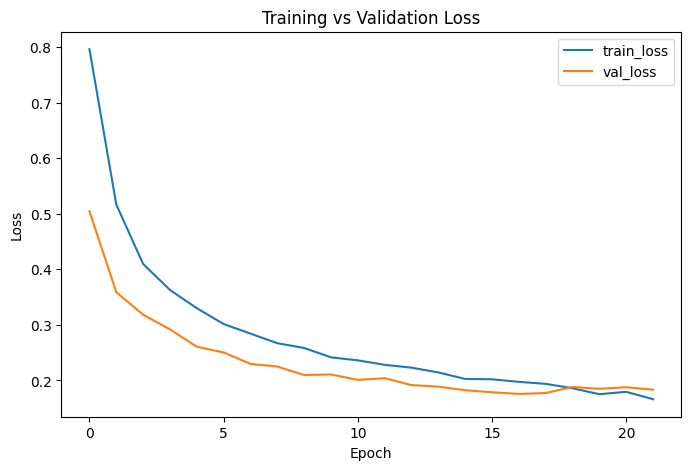

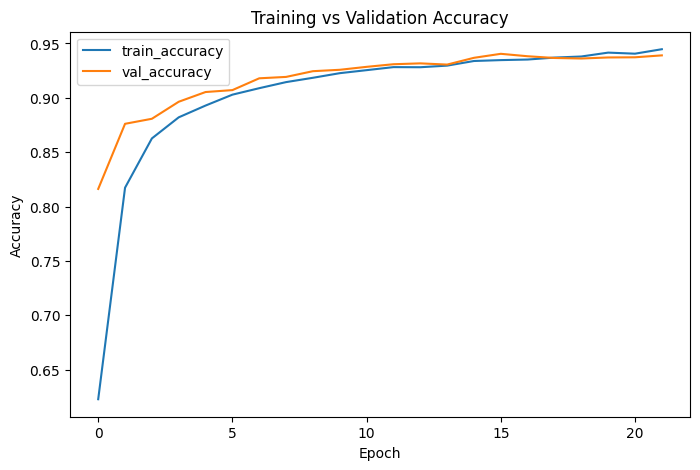

History head:
   accuracy      loss  val_accuracy  val_loss  learning_rate
0  0.622838  0.796248      0.816193  0.504399         0.0005
1  0.817333  0.516557      0.876078  0.358793         0.0005
2  0.862643  0.409596      0.880709  0.318294         0.0005
3  0.882035  0.362828      0.896359  0.291851         0.0005
4  0.892863  0.330061      0.905302  0.260716         0.0005


In [27]:
# ================================
# Cell 23: Plot training curves
# ================================

# This cell plots the training history of the LSTM model.
#
# history_df was created after model.fit().
# It contains training metrics for each epoch.
#
# Usually it includes columns like:
# - loss
# - accuracy
# - val_loss
# - val_accuracy


# Create a new figure for the loss graph.
#
# figsize=(8, 5) means:
# width = 8 inches
# height = 5 inches
plt.figure(figsize=(8, 5))


# Plot training loss across epochs.
#
# history_df["loss"] contains loss values on training data.
plt.plot(
    history_df["loss"],
    label="train_loss"
)


# Plot validation loss across epochs.
#
# history_df["val_loss"] contains loss values on validation data.
plt.plot(
    history_df["val_loss"],
    label="val_loss"
)


# Set x-axis label.
#
# Epoch means one full training pass over the training data.
plt.xlabel("Epoch")


# Set y-axis label.
#
# Loss measures model error.
# Lower loss is usually better.
plt.ylabel("Loss")


# Set graph title.
plt.title("Training vs Validation Loss")


# Show legend.
#
# Legend displays labels:
# train_loss
# val_loss
plt.legend()


# Display the loss plot.
plt.show()


# Create a new figure for the accuracy graph.
plt.figure(figsize=(8, 5))


# Plot training accuracy across epochs.
#
# history_df["accuracy"] contains accuracy on training data.
plt.plot(
    history_df["accuracy"],
    label="train_accuracy"
)


# Plot validation accuracy across epochs.
#
# history_df["val_accuracy"] contains accuracy on validation data.
plt.plot(
    history_df["val_accuracy"],
    label="val_accuracy"
)


# Set x-axis label.
plt.xlabel("Epoch")


# Set y-axis label.
#
# Accuracy means percentage of correct predictions.
plt.ylabel("Accuracy")


# Set graph title.
plt.title("Training vs Validation Accuracy")


# Show legend.
plt.legend()


# Display the accuracy plot.
plt.show()


# Print first few rows of training history.
#
# This helps inspect exact numeric values for each epoch.
print("History head:")
print(history_df.head())

# Cell 24: Optional Label Shuffle Test

This cell is an optional leakage test.

The purpose of this test is to check whether the model is learning real patterns or accidentally using leaked information.

The idea is simple:

1. Shuffle the training labels randomly.
2. Train a small LSTM model using the same input features.
3. Evaluate the model on the real test labels.

If the model still gets high accuracy after training with shuffled labels, that is a warning sign.

Why?

Because when labels are shuffled, the relationship between input features and output labels is destroyed.  
A proper model should not be able to learn meaningful behaviour from random labels.

Expected result:

- Label-shuffle accuracy should be low.
- If accuracy is high, there may be data leakage.

This test is optional because it takes extra training time.

By default:

- `RUN_LABEL_SHUFFLE_TEST = False`

So the test is skipped.

To run it, change:

- `RUN_LABEL_SHUFFLE_TEST = True`

In simple words, this cell asks:

“Can the model still perform well when the labels are random?”

If yes, something may be wrong.  
If no, the dataset is more trustworthy.

In [28]:
# ================================
# Cell 24: Optional label shuffle test
# ================================

# This cell is an optional leakage/sanity test.
#
# The idea:
# If we shuffle the training labels randomly,
# the model should NOT be able to learn meaningful patterns.
#
# If the model still gets high accuracy after shuffled-label training,
# there may be data leakage or some hidden target information in features.


# Control whether to run the label shuffle test.
#
# False means skip the test.
# True means run the test.
#
# This is set to False by default because it takes extra training time.
RUN_LABEL_SHUFFLE_TEST = False


# If RUN_LABEL_SHUFFLE_TEST is True, run the shuffle test.
if RUN_LABEL_SHUFFLE_TEST:

    # Shuffle y_train randomly.
    #
    # np.random.permutation keeps the same label values
    # but changes their order randomly.
    #
    # This destroys the correct relationship between X_train and y_train.
    #
    # Example:
    # original:
    # sequence A -> GO
    # sequence B -> YIELD
    #
    # after shuffle:
    # sequence A -> NEUTRAL
    # sequence B -> GO
    shuffled_y_train = np.random.permutation(y_train)


    # Build a smaller LSTM model for the shuffle test.
    #
    # This model is intentionally smaller than the main model
    # because this is only a diagnostic test.
    shuffle_model = Sequential([

        # Masking layer.
        #
        # Same input shape as the main LSTM model:
        # SEQUENCE_LENGTH × number_of_features
        Masking(
            mask_value=0.0,
            input_shape=(SEQUENCE_LENGTH, X.shape[2])
        ),


        # Smaller LSTM layer with 16 units.
        #
        # It still learns sequences, but with fewer parameters.
        LSTM(
            16,
            return_sequences=False
        ),


        # Dropout to reduce memorization.
        Dropout(0.40),


        # Output layer.
        #
        # num_classes is usually 3:
        # GO, NEUTRAL, YIELD.
        Dense(
            num_classes,
            activation="softmax"
        ),
    ])


    # Compile the shuffle test model.
    #
    # sparse_categorical_crossentropy is used because labels are integer encoded.
    shuffle_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # Train the shuffle model using shuffled labels.
    #
    # Important:
    # X_train is real.
    # shuffled_y_train is random.
    #
    # So the model should not learn real behaviour.
    shuffle_model.fit(
        X_train,
        shuffled_y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=128,
        verbose=1
    )


    # Evaluate the shuffle model on the real test labels.
    #
    # If accuracy is high, that is suspicious.
    shuffle_loss, shuffle_acc = shuffle_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )


    # Print shuffle test accuracy.
    print("Label-shuffle test accuracy:", shuffle_acc)


    # Explain interpretation.
    print("If this is high, there is likely data leakage.")


# If RUN_LABEL_SHUFFLE_TEST is False, skip the test.
else:

    # Print message explaining how to run the test.
    print("Label shuffle test skipped. Set RUN_LABEL_SHUFFLE_TEST=True to run it.")


# Print dataset head for reference.
#
# This lets us inspect the current V2V dataset structure.
print("Dataset head for reference:")
print(v2v_dataset.head())

Label shuffle test skipped. Set RUN_LABEL_SHUFFLE_TEST=True to run it.
Dataset head for reference:
   recordingId  trackId  frame  time_s     ego_x     ego_y  ego_speed  \
0            7        0      0     0.0  49.08017 -24.74120   9.652994   
1            7        0      5     0.2  47.79139 -23.21621  10.130885   
2            7        0     10     0.4  46.42682 -21.62622  10.491162   
3            7        8     10     0.4  77.01180 -54.71720  11.667679   
4            7        0     15     0.6  45.03725 -20.00140  10.720277   

   ego_acceleration  ego_signed_acceleration  ego_heading_sin  ...  \
0          2.001056                  1.97928         0.761123  ...   
1          1.855361                  1.83972         0.760015  ...   
2          1.424843                  1.41797         0.758710  ...   
3          2.314456                  2.14487         0.738629  ...   
4          0.999680                  0.99688         0.758482  ...   

   context_vehicle_count  nearest_vehicle

# Cell 24: Label Shuffle Leakage Test

This cell performs a stronger label shuffle leakage test.

The purpose of this test is to check whether the model is really learning meaningful relationships between input features and labels, or whether it may be benefiting from data leakage.

In normal training:

- `X_train` contains real LSTM input sequences.
- `y_train` contains the correct labels.

In this test:

- `X_train` is kept the same.
- `y_train` is randomly shuffled.

This destroys the correct relationship between input sequences and labels.

Then a fresh LSTM model is trained using these shuffled labels.

Expected result:

- The shuffled-label model should perform poorly.
- Balanced accuracy and macro F1 should be low.
- If performance is still very high, then there may be leakage or hidden target information in the input features.

This version is stronger than only checking accuracy because it also calculates:

- normal accuracy
- balanced accuracy
- macro F1
- classification report

Balanced accuracy and macro F1 are more important for this project because the dataset is imbalanced and YIELD is a minority but safety-important class.

In simple words, this cell asks:

“If the labels are random, can the model still perform well?”

If yes, something may be wrong.  
If no, leakage is less likely.

In [29]:
# ================================
# Cell 24: Label Shuffle Leakage Test
# ================================

# This cell runs a label shuffle leakage test.
#
# Purpose:
# Check whether the model is learning real patterns
# or accidentally using leaked information.
#
# Main idea:
# Keep X_train the same, but randomly shuffle y_train.
# If labels are random, a proper model should not perform well.


# Set this to True to run the label shuffle test.
#
# This test trains an additional model, so it takes extra time.
RUN_LABEL_SHUFFLE_TEST = True


# Run the test only if RUN_LABEL_SHUFFLE_TEST is True.
if RUN_LABEL_SHUFFLE_TEST:

    # Print message to show the test has started.
    print("Running label shuffle leakage test...")


    # Shuffle only the training labels.
    #
    # X_train stays the same.
    # y_train is shuffled randomly.
    #
    # This destroys the real relationship between:
    # input sequence -> correct behaviour label
    #
    # Example:
    # before shuffle:
    # sequence A -> GO
    # sequence B -> YIELD
    #
    # after shuffle:
    # sequence A -> NEUTRAL
    # sequence B -> GO
    y_train_shuffled = y_train.copy()


    # Set random seed for reproducibility.
    #
    # This means the shuffle result will be the same
    # every time you run this cell.
    np.random.seed(42)


    # Shuffle labels in-place.
    #
    # The values are the same labels,
    # but their order is randomized.
    np.random.shuffle(y_train_shuffled)


    # Build a fresh model with the same architecture as the main model.
    #
    # Important:
    # We do not reuse the trained model.
    # We create a new model from scratch for this test.
    shuffle_model = Sequential([

        # Masking layer.
        #
        # Input shape uses:
        # X_train.shape[1] = sequence length
        # X_train.shape[2] = number of features
        #
        # Example:
        # input shape = (10, 34)
        Masking(
            mask_value=0.0,
            input_shape=(X_train.shape[1], X_train.shape[2])
        ),


        # LSTM layer with 32 units.
        #
        # This matches the main model architecture.
        LSTM(
            32,
            return_sequences=False
        ),


        # Dropout layer.
        #
        # Randomly disables 30% of neurons during training
        # to reduce memorization.
        Dropout(0.30),


        # Dense hidden layer.
        Dense(
            16,
            activation="relu"
        ),


        # Another dropout layer.
        Dropout(0.30),


        # Output layer.
        #
        # num_classes is usually 3:
        # GO, NEUTRAL, YIELD.
        Dense(
            num_classes,
            activation="softmax"
        ),
    ])


    # Compile the shuffle model.
    #
    # Same loss as main model because labels are integer encoded.
    shuffle_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # Train the shuffle model using shuffled labels.
    #
    # X_train = real input sequences.
    # y_train_shuffled = random labels.
    #
    # validation_data uses real validation labels.
    # Therefore, validation performance should usually be poor.
    shuffle_model.fit(
        X_train,
        y_train_shuffled,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1
    )


    # Evaluate the shuffle model on the real test set.
    #
    # Since the model learned from random labels,
    # it should not perform well on real test labels.
    shuffle_loss, shuffle_acc = shuffle_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )


    # Predict probabilities on test data.
    #
    # Output shape:
    # number_of_test_samples × number_of_classes
    shuffle_probs = shuffle_model.predict(X_test)


    # Convert predicted probabilities into class IDs.
    #
    # Highest probability class becomes the prediction.
    shuffle_pred = np.argmax(
        shuffle_probs,
        axis=1
    )


    # Calculate balanced accuracy.
    #
    # This is important for imbalanced datasets.
    # It gives equal importance to GO, NEUTRAL, and YIELD.
    shuffle_bal_acc = balanced_accuracy_score(
        y_test,
        shuffle_pred
    )


    # Calculate macro F1.
    #
    # Macro F1 also gives equal importance to all classes.
    # It is useful because YIELD is a minority class.
    shuffle_macro_f1 = f1_score(
        y_test,
        shuffle_pred,
        average="macro"
    )


    # Print shuffle test loss.
    print("Shuffle test loss:", shuffle_loss)


    # Print normal accuracy.
    #
    # Normal accuracy can still look misleading
    # if the model predicts the majority class often.
    print("Shuffle test accuracy:", shuffle_acc)


    # Print balanced accuracy.
    #
    # This is more important than normal accuracy for this test.
    print("Shuffle balanced accuracy:", shuffle_bal_acc)


    # Print macro F1 score.
    #
    # This is also important for checking class-wise performance.
    print("Shuffle macro F1:", shuffle_macro_f1)


    # Print classification report.
    #
    # This shows precision, recall, and F1-score for each class.
    print("\nShuffle classification report:")
    print(
        classification_report(
            y_test,
            shuffle_pred,
            target_names=label_encoder.classes_
        )
    )


    # Print interpretation help.
    print("\nInterpretation:")
    print("- If shuffle balanced accuracy and macro F1 are low, leakage is less likely.")
    print("- If shuffle balanced accuracy and macro F1 are still very high, there may still be leakage.")


# If RUN_LABEL_SHUFFLE_TEST is False, skip the test.
else:

    # Print message explaining how to run it.
    print("Label shuffle test skipped. Set RUN_LABEL_SHUFFLE_TEST=True to run it.")


# Print dataset head for reference.
#
# This helps verify the V2V dataset structure.
print("Dataset head for reference:")
print(v2v_dataset.head())

Running label shuffle leakage test...
Epoch 1/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7222 - loss: 0.8001 - val_accuracy: 0.7799 - val_loss: 0.6790
Epoch 2/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7779 - loss: 0.7164 - val_accuracy: 0.7799 - val_loss: 0.6772
Epoch 3/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7781 - loss: 0.7043 - val_accuracy: 0.7799 - val_loss: 0.6768
Epoch 4/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7781 - loss: 0.6966 - val_accuracy: 0.7799 - val_loss: 0.6785
Epoch 5/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7781 - loss: 0.6932 - val_accuracy: 0.7799 - val_loss: 0.6778
Epoch 6/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7781 - loss: 0.6884 - val_accuracy: 0.7799 - val_loss: 0.6806
Epoch 7/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7781 - loss: 0.6861 - val_accuracy: 0.7799 - val_loss: 0.6820
Epoch 8/10
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accu

# Cell 25: Save Artifacts and  Report

This cell saves the final project outputs.

After training and evaluating the V2V-aware LSTM model, we need to save important artifacts so they can be reused later.

This cell saves:

1. Trained LSTM model
   - Saved as `.keras`
   - This can be loaded later for prediction or SUMO integration.

2. Feature scaler
   - Saved as `.pkl`
   - This is important because future/SUMO input features must be scaled using the same scaler used during training.

3. Label encoder
   - Saved as `.pkl`
   - This converts numeric model outputs back into labels such as GO, NEUTRAL, and YIELD.

4. Training history
   - Saved as `.csv`
   - This stores loss and accuracy values for each epoch.

5. report
   - Saved as `.txt`
   - This report summarizes what was improved, why the previous high accuracy was suspicious, what leakage controls were added, and what the final results were.

This cell is useful for PP1 because it creates files that can be shown as evidence:

- model file
- scaler file
- label encoder file
- training history
- report summary

In simple words, this cell packages the completed model, preprocessing tools, results, and explanation into saved files.

In [30]:
# ================================
# Cell 25: Save artifacts and supervisor report
# ================================

# This cell saves the final trained model and supporting files.
#
# These saved files are called artifacts.
#
# Artifacts are important because after training, we need to reuse:
# - the trained model
# - the scaler
# - the label encoder
# - the training history
# - the supervisor/report summary


# Create path to save the trained LSTM model.
#
# The model is saved in Keras format.
# This file can later be loaded for prediction or SUMO integration.
model_path = os.path.join(
    OUTPUT_DIR,
    "v2v_lstm_observed_behavior_model.keras"
)


# Create path to save the feature scaler.
#
# The scaler was fitted on training data in Cell 19.
# It must be reused later when predicting with new/SUMO data.
scaler_path = os.path.join(
    OUTPUT_DIR,
    "feature_scaler_observed_behavior.pkl"
)


# Create path to save the label encoder.
#
# The label encoder converts:
# GO / NEUTRAL / YIELD
# into numeric classes and back.
encoder_path = os.path.join(
    OUTPUT_DIR,
    "label_encoder_observed_behavior.pkl"
)


# Create path to save training history.
#
# This contains loss, accuracy, validation loss, and validation accuracy
# for each training epoch.
history_path = os.path.join(
    OUTPUT_DIR,
    "training_history_observed_behavior.csv"
)


# Create path to save supervisor report.
#
# This text report summarizes the model pipeline and results.
report_path = os.path.join(
    OUTPUT_DIR,
    "supervisor_report_observed_behavior.txt"
)


# Save the trained Keras model.
#
# Later, you can load it using:
# tf.keras.models.load_model(model_path)
model.save(model_path)


# Save the fitted scaler using joblib.
#
# This is needed because new input features must be scaled in the same way
# as training data.
joblib.dump(
    scaler,
    scaler_path
)


# Save the label encoder using joblib.
#
# This helps convert predicted numeric classes back to text labels.
joblib.dump(
    label_encoder,
    encoder_path
)


# Save training history dataframe as CSV.
#
# index=False means do not save pandas row index as an extra column.
history_df.to_csv(
    history_path,
    index=False
)


# Create an empty list to store report text lines.
#
# Later, all lines are written into a text file.
report_lines = []


# Add report title.
report_lines.append("Professional V2V LSTM Observed-Behaviour Report")


# Add separator line.
report_lines.append("=" * 80)


# Add empty line.
report_lines.append("")


# Explain why the previous very high accuracy was suspicious.
report_lines.append("Why the previous 98% accuracy was suspicious:")


# Add explanation.
#
# This is important because if labels were rule-generated
# and model features contained rule-related columns,
# then the model may learn the rule instead of real behaviour.
report_lines.append(
    "The previous dataset used deterministic rule-generated labels and included features directly related to those same rules. The model could therefore learn the rule rather than real driving behaviour."
)


# Add empty line.
report_lines.append("")


# Add section heading.
report_lines.append("Main improvements in this notebook:")


# Improvement 1:
# All selected recordings are processed.
report_lines.append("1. All recordings 07-17 are processed.")


# Improvement 2:
# Static/parked/short tracks are removed.
report_lines.append("2. Parked/static/short tracks are removed.")


# Improvement 3:
# Intersection center is estimated after filtering.
report_lines.append("3. Intersection center is estimated after moving-vehicle filtering.")


# Improvement 4:
# Maneuver inference is improved using trajectory segments.
report_lines.append("4. Maneuver is inferred using trajectory segments, not only first/last frame.")


# Improvement 5:
# Labels are created from observed future movement.
report_lines.append("5. Labels are generated from future observed vehicle motion, not current V2V rule output.")


# Improvement 6:
# Leakage columns are not used.
report_lines.append("6. Leakage columns such as previous GO/YIELD counts are not used as model features.")


# Improvement 7:
# Recording-wise split is used.
report_lines.append("7. Recording-wise split keeps recordings 16-17 unseen for final testing.")


# Add empty line.
report_lines.append("")


# Add recordings included in all processed dataframe.
#
# all_df was created earlier after processing all recordings.
report_lines.append(
    f"Recordings in all_df: {sorted(all_df['recordingId'].unique())}"
)


# Add number of processed frame rows.
report_lines.append(
    f"Processed frame rows: {len(all_df)}"
)


# Add number of V2V dataset rows.
#
# v2v_dataset was created in Cell 15.
report_lines.append(
    f"V2V dataset rows: {len(v2v_dataset)}"
)


# Add LSTM sequence shape.
#
# Example:
# (73672, 10, 34)
report_lines.append(
    f"Sequence shape: {X.shape}"
)


# Add training recordings.
report_lines.append(
    f"Train recordings: {train_recordings}"
)


# Add validation recordings.
report_lines.append(
    f"Validation recordings: {val_recordings}"
)


# Add test recordings.
report_lines.append(
    f"Test recordings: {test_recordings}"
)


# Add label class names.
report_lines.append(
    f"Label classes: {list(label_encoder.classes_)}"
)


# Add empty line.
report_lines.append("")


# Add final metrics section heading.
report_lines.append("Final test metrics:")


# Add normal test accuracy.
report_lines.append(
    f"Normal accuracy: {test_acc}"
)


# Add balanced accuracy.
#
# This is important for imbalanced datasets.
report_lines.append(
    f"Balanced accuracy: {balanced_acc}"
)


# Add macro F1 score.
#
# This is also important for class-wise fair evaluation.
report_lines.append(
    f"Macro F1: {macro_f1}"
)


# Add empty line.
report_lines.append("")


# Add interpretation section.
report_lines.append("Important interpretation:")


# Add interpretation text.
#
# This reminds the reader that high accuracy alone is not enough.
# The model should also be compared with baseline, balanced accuracy,
# macro F1, and confusion matrix.
report_lines.append(
    "If the model still achieves very high accuracy, compare it against the majority baseline and run the optional label-shuffle test. High accuracy is only meaningful if balanced accuracy, macro F1, and confusion matrix are also strong."
)


# Open the report file in write mode.
#
# "w" means write.
# If the file already exists, it will be overwritten.
with open(report_path, "w") as f:

    # Write all report lines into the text file.
    #
    # NOTE:
    # Your original code uses "".join(report_lines).
    # That writes all lines without new line breaks.
    #
    # Better version:
    # "\n".join(report_lines)
    #
    # This makes the report easier to read.
    f.write("\n".join(report_lines))


# Print saved artifact paths.
print("Artifacts saved:")


# Print trained model path.
print("Model:", model_path)


# Print scaler path.
print("Scaler:", scaler_path)


# Print label encoder path.
print("Encoder:", encoder_path)


# Print training history path.
print("History:", history_path)


# Print supervisor report path.
print("Report:", report_path)


# Print first few rows of final V2V dataset.
#
# This is just for final reference.
print("Final dataset head:")
print(v2v_dataset.head())

Artifacts saved:
Model: /content/v2v_lstm_observed_behavior_outputs/v2v_lstm_observed_behavior_model.keras
Scaler: /content/v2v_lstm_observed_behavior_outputs/feature_scaler_observed_behavior.pkl
Encoder: /content/v2v_lstm_observed_behavior_outputs/label_encoder_observed_behavior.pkl
History: /content/v2v_lstm_observed_behavior_outputs/training_history_observed_behavior.csv
Report: /content/v2v_lstm_observed_behavior_outputs/supervisor_report_observed_behavior.txt
Final dataset head:
   recordingId  trackId  frame  time_s     ego_x     ego_y  ego_speed  \
0            7        0      0     0.0  49.08017 -24.74120   9.652994   
1            7        0      5     0.2  47.79139 -23.21621  10.130885   
2            7        0     10     0.4  46.42682 -21.62622  10.491162   
3            7        8     10     0.4  77.01180 -54.71720  11.667679   
4            7        0     15     0.6  45.03725 -20.00140  10.720277   

   ego_acceleration  ego_signed_acceleration  ego_heading_sin  ...  \
0 